In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
sns.set(color_codes=True)
%matplotlib inline
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [27]:
#To display comments/observations in 'orange' color and bold
def b(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Observations:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def f(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Final Comments:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")

## 1. Load the dataset

In [28]:
df_org = pd.read_csv('Data - Parkinsons')

In [29]:
pd.set_option('display.max_columns',70)

## 2. It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of records, structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. Mention a few comments in this regard

In [30]:
df_org.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [31]:
df_org.tail()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,0.02336,0.02498,0.02745,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,0.01604,0.01657,0.01879,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,0.01268,0.01365,0.01667,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,0.01265,0.01321,0.01588,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306
194,phon_R01_S50_6,214.289,260.277,77.973,0.00567,0.00003,0.00295,0.00317,0.00885,0.01884,0.190,0.01026,0.01161,0.01373,0.03078,0.04398,21.209,0,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569


In [32]:
df_org.shape

(195, 24)

In [33]:
df_org.nunique()

name                195
MDVP:Fo(Hz)         195
MDVP:Fhi(Hz)        195
MDVP:Flo(Hz)        195
MDVP:Jitter(%)      173
MDVP:Jitter(Abs)     19
MDVP:RAP            155
MDVP:PPQ            165
Jitter:DDP          180
MDVP:Shimmer        188
MDVP:Shimmer(dB)    149
Shimmer:APQ3        184
Shimmer:APQ5        189
MDVP:APQ            189
Shimmer:DDA         189
NHR                 185
HNR                 195
status                2
RPDE                195
DFA                 195
spread1             195
spread2             194
D2                  195
PPE                 195
dtype: int64

In [34]:
for i in list(df_org.columns):
    print("\n Column name: '{0}' \n-------------------\n=> No. of unique values: {1}\n=> Unique values: {2}  ".format(i, df_org[i].nunique(), df_org[i].unique()))


 Column name: 'name' 
-------------------
=> No. of unique values: 195
=> Unique values: ['phon_R01_S01_1' 'phon_R01_S01_2' 'phon_R01_S01_3' 'phon_R01_S01_4'
 'phon_R01_S01_5' 'phon_R01_S01_6' 'phon_R01_S02_1' 'phon_R01_S02_2'
 'phon_R01_S02_3' 'phon_R01_S02_4' 'phon_R01_S02_5' 'phon_R01_S02_6'
 'phon_R01_S04_1' 'phon_R01_S04_2' 'phon_R01_S04_3' 'phon_R01_S04_4'
 'phon_R01_S04_5' 'phon_R01_S04_6' 'phon_R01_S05_1' 'phon_R01_S05_2'
 'phon_R01_S05_3' 'phon_R01_S05_4' 'phon_R01_S05_5' 'phon_R01_S05_6'
 'phon_R01_S06_1' 'phon_R01_S06_2' 'phon_R01_S06_3' 'phon_R01_S06_4'
 'phon_R01_S06_5' 'phon_R01_S06_6' 'phon_R01_S07_1' 'phon_R01_S07_2'
 'phon_R01_S07_3' 'phon_R01_S07_4' 'phon_R01_S07_5' 'phon_R01_S07_6'
 'phon_R01_S08_1' 'phon_R01_S08_2' 'phon_R01_S08_3' 'phon_R01_S08_4'
 'phon_R01_S08_5' 'phon_R01_S08_6' 'phon_R01_S10_1' 'phon_R01_S10_2'
 'phon_R01_S10_3' 'phon_R01_S10_4' 'phon_R01_S10_5' 'phon_R01_S10_6'
 'phon_R01_S13_1' 'phon_R01_S13_2' 'phon_R01_S13_3' 'phon_R01_S13_4'
 'phon_R01_S1

In [35]:
b("Where the columns 'status'(categorical) is the target variable and rest of the columns(continous) are predictors ignoring the column 'name'(nomial) as it's unique and doesn't contribute much in the prediction")
df_org.columns

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Where the columns 'status'(categorical) is the target variable and rest of the columns(continous) are predictors ignoring the column 'name'(nomial) as it's unique and doesn't contribute much in the prediction 


Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [36]:
df_org.count()

name                195
MDVP:Fo(Hz)         195
MDVP:Fhi(Hz)        195
MDVP:Flo(Hz)        195
MDVP:Jitter(%)      195
MDVP:Jitter(Abs)    195
MDVP:RAP            195
MDVP:PPQ            195
Jitter:DDP          195
MDVP:Shimmer        195
MDVP:Shimmer(dB)    195
Shimmer:APQ3        195
Shimmer:APQ5        195
MDVP:APQ            195
Shimmer:DDA         195
NHR                 195
HNR                 195
status              195
RPDE                195
DFA                 195
spread1             195
spread2             195
D2                  195
PPE                 195
dtype: int64

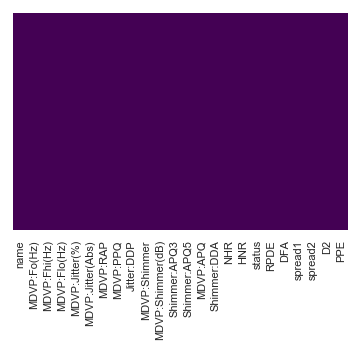

In [37]:
#plt.figure(figsize=(10,20))
sns.heatmap(df_org.isnull(), yticklabels=False, cbar=False, cmap='viridis');

In [38]:
def is_null_present(df=df_org):
    is_null = False
    if df.isnull().any().any() == False:
        b("==> There are no null or missing values found in the given dataset.")
    else:
        b("==> There are null values present in the dataset.")
        is_null = True
    return is_null

In [39]:
is_null_present()

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no null or missing values found in the given dataset. 


False

In [40]:
df_org.info()
b("Data type of each attribute is as expected.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [41]:
df_org.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


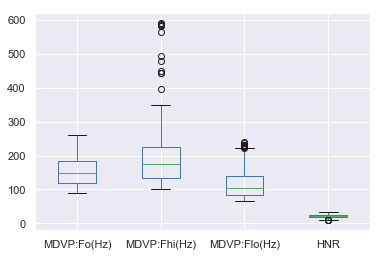

In [42]:
df_org.boxplot(column=['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)','HNR' ])

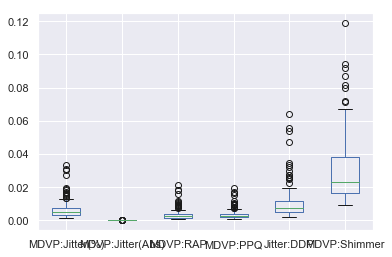

In [43]:
df_org.boxplot(column=['MDVP:Jitter(%)','MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP','MDVP:Shimmer'])
 

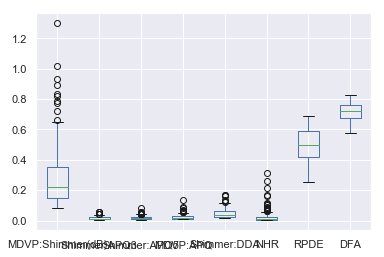

In [44]:
df_org.boxplot(column=['MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5','MDVP:APQ', 'Shimmer:DDA', 'NHR', 'RPDE', 'DFA'])


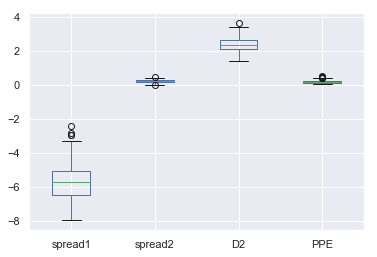

In [45]:
df_org.boxplot(column=['spread1', 'spread2', 'D2', 'PPE'])

In [46]:
df_org['status'].value_counts()

1    147
0     48
Name: status, dtype: int64

In [47]:
round((df_org['status'].value_counts()/len(df_org['status']))*100,2) # 1- diagnosed w/ disease 'PD'; 0-not diagnosed w/ disease 'PD'

1    75.38
0    24.62
Name: status, dtype: float64

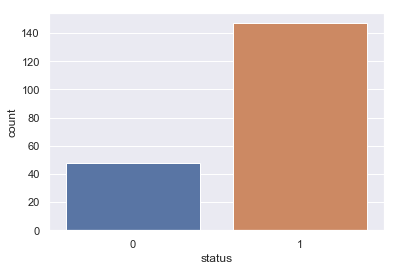

In [48]:
sns.countplot(df_org.status)

In [49]:
b("1. There are attributes with different measures and units. All these column values have to be scaled into a single range using any Normalization technique.\n 2. There is a class imbalance in the target columns. Disease(1) record count is much higher than non-disease(0) record count.\n 3. There are outliers in the columns such as 'MDVP:Fhi(Hz)', 'MDVP:Jitter(%)','MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP','MDVP:Shimmer', 'MDVP:Shimmer(dB)', NHR.\n 4. There are columns, whose values are positively/right skewed such as 'MDVP:Shimmer', 'MDVP:Shimmer(dB)'.\n 4. There are few columns with negative value such as 'spread1'(seems like data nature considering domain))")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 1. There are attributes with different measures and units. All these column values have to be scaled into a single range using any Normalization technique.
 2. There is a class imbalance in the target columns. Disease(1) record count is much higher than non-disease(0) record count.
 3. There are outliers in the columns such as 'MDVP:Fhi(Hz)', 'MDVP:Jitter(%)','MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP','MDVP:Shimmer', 'MDVP:Shimmer(dB)', NHR.
 4. There are columns, whose values are positively/right skewed such as 'MDVP:Shimmer', 'MDVP:Shimmer(dB)'.
 4. There are few columns with negative value such as 'spread1'(seems like data nature considering domain)) 


## 3. Using univariate & bivariate analysis to check the individual attributes for their basic statistics such as central values, spread, tails, relationships between variables etc. mention your observations

In [50]:
df_org.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 It seems that column 'HNR' is negatively correlated with other attributes. Also, it seems that columns 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5','MDVP:APQ', 'Shimmer:DDA' are highlighly correlated to each other. As we approach it as classification, I'm not eliminating any attributes ever though there is multi collinearity. 


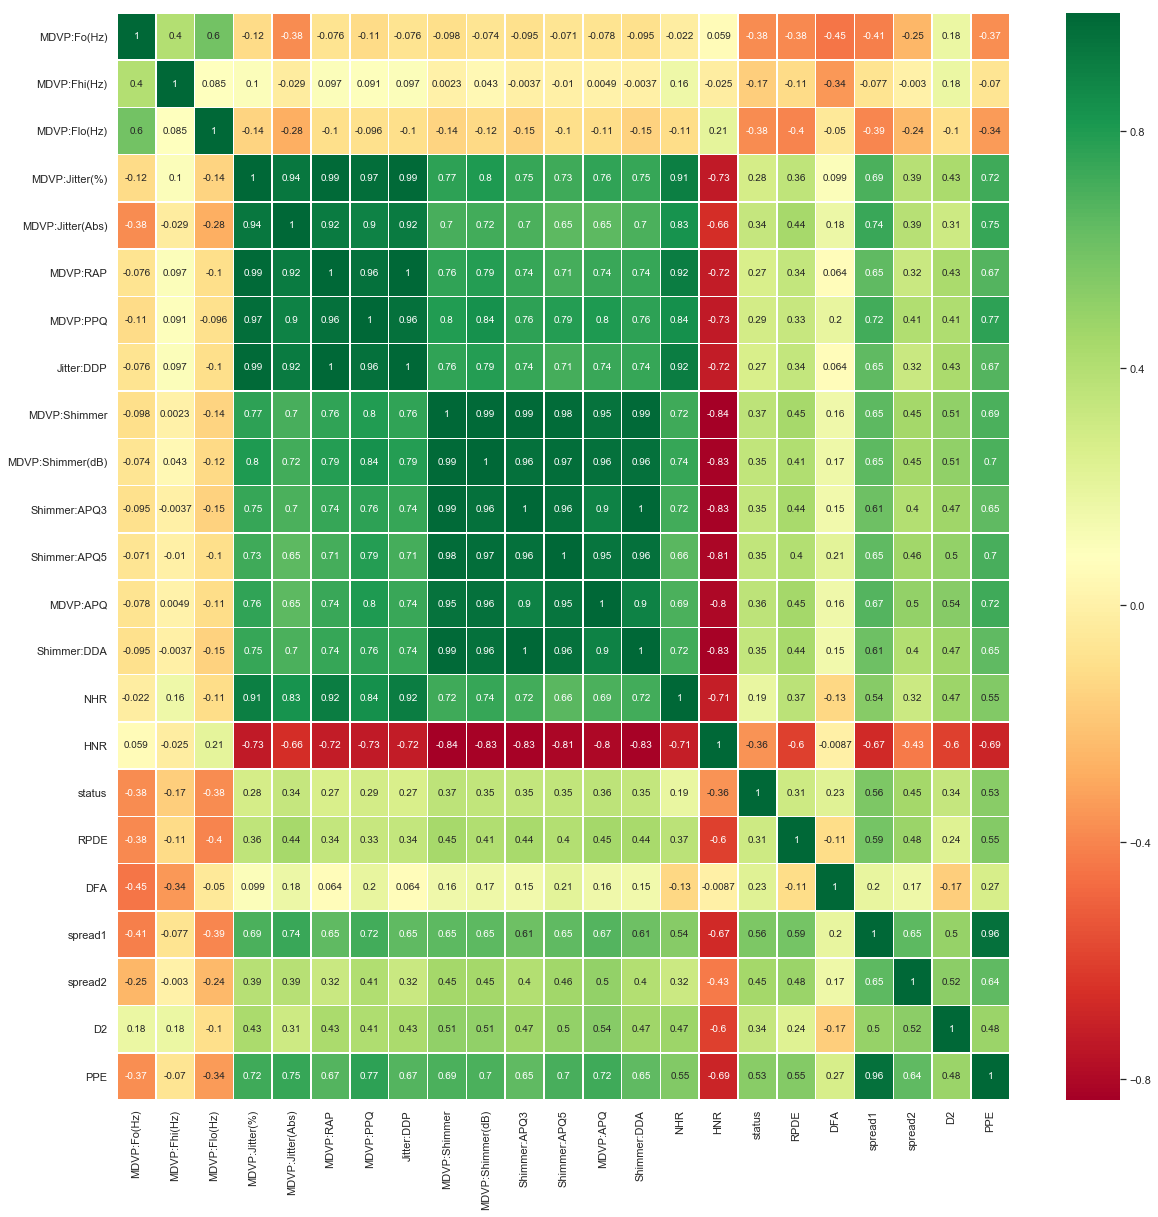

In [51]:
plt.figure(figsize=(20,20))
sns.heatmap(df_org.corr(), annot=True, linewidth=0.5, cmap='RdYlGn')
b("It seems that column 'HNR' is negatively correlated with other attributes. Also, it seems that columns 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5','MDVP:APQ', 'Shimmer:DDA' are highlighly correlated to each other. As we approach it as classification, I'm not eliminating any attributes ever though there is multi collinearity.")

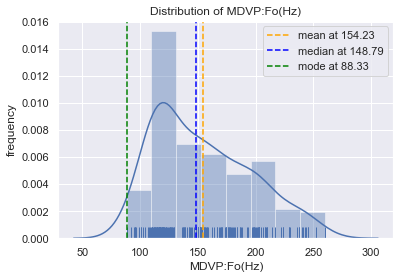

In [52]:
sns.distplot(df_org['MDVP:Fo(Hz)'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:Fo(Hz)")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:Fo(Hz)")
measurements = [round(df_org['MDVP:Fo(Hz)'].mean(),2), round(df_org['MDVP:Fo(Hz)'].median(),2), round(df_org['MDVP:Fo(Hz)'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

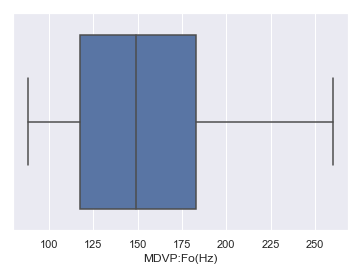

In [53]:
sns.boxplot(df_org['MDVP:Fo(Hz)']);

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:Fo(Hz)' data seems to be approximately normally distributed without having any outliers. Also, it seems the people who do have 'MDVP:Fo(Hz)'>'=200' are potentially not diagnosed with the disease 'PD' 


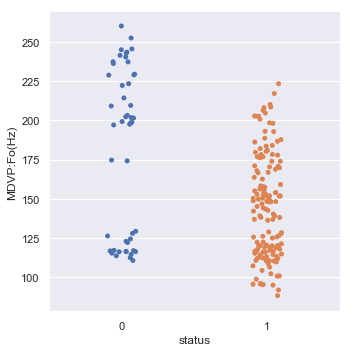

In [54]:
sns.catplot(x='status',  y='MDVP:Fo(Hz)', data=df_org, jitter=True)
b("Column 'MDVP:Fo(Hz)' data seems to be approximately normally distributed without having any outliers. Also, it seems the people who do have 'MDVP:Fo(Hz)'>'=200' are potentially not diagnosed with the disease 'PD'")

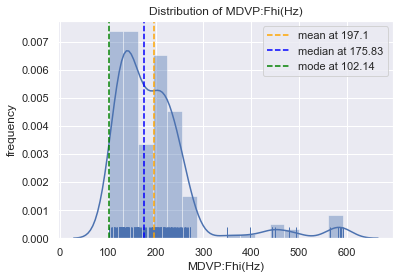

In [55]:
sns.distplot(df_org['MDVP:Fhi(Hz)'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:Fhi(Hz)")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:Fhi(Hz)")
measurements = [round(df_org['MDVP:Fhi(Hz)'].mean(),2), round(df_org['MDVP:Fhi(Hz)'].median(),2), round(df_org['MDVP:Fhi(Hz)'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:Fhi(Hz)' data seems to be right skewed with few outliers 


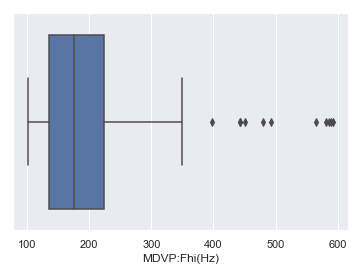

In [56]:
sns.boxplot(df_org['MDVP:Fhi(Hz)']);
b("Column 'MDVP:Fhi(Hz)' data seems to be right skewed with few outliers")

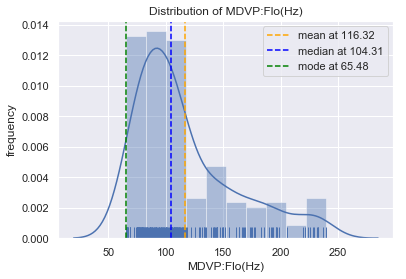

In [57]:
sns.distplot(df_org['MDVP:Flo(Hz)'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:Flo(Hz)")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:Flo(Hz)")
measurements = [round(df_org['MDVP:Flo(Hz)'].mean(),2), round(df_org['MDVP:Flo(Hz)'].median(),2), round(df_org['MDVP:Flo(Hz)'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:Flo(Hz)' data seems to be right skewed with few outliers 


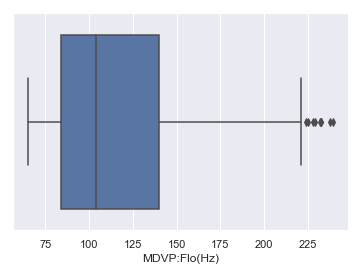

In [58]:
sns.boxplot(df_org['MDVP:Flo(Hz)']);
b("Column 'MDVP:Flo(Hz)' data seems to be right skewed with few outliers")

In [59]:
df_org.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

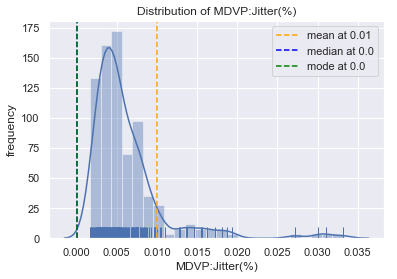

In [60]:
sns.distplot(df_org['MDVP:Jitter(%)'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:Jitter(%)")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:Jitter(%)")
measurements = [round(df_org['MDVP:Jitter(%)'].mean(),2), round(df_org['MDVP:Jitter(%)'].median(),2), round(df_org['MDVP:Jitter(%)'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:Jitter(%)' data seems to be right skewed with few outliers 


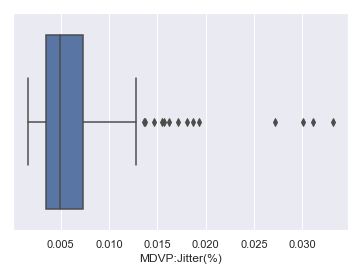

In [61]:
sns.boxplot(df_org['MDVP:Jitter(%)']);
b("Column 'MDVP:Jitter(%)' data seems to be right skewed with few outliers")

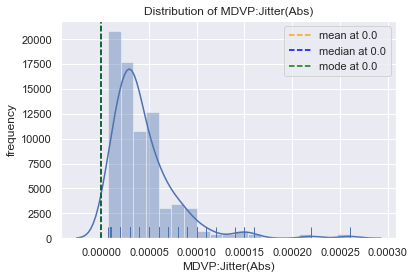

In [62]:
sns.distplot(df_org['MDVP:Jitter(Abs)'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:Jitter(Abs)")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:Jitter(Abs)")
measurements = [round(df_org['MDVP:Jitter(Abs)'].mean(),2), round(df_org['MDVP:Jitter(Abs)'].median(),2), round(df_org['MDVP:Jitter(Abs)'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:Jitter(Abs)' data seems to be right skewed with very few outliers 


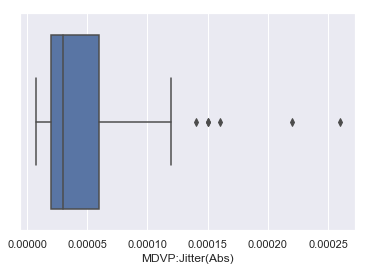

In [63]:
sns.boxplot(df_org['MDVP:Jitter(Abs)']);
b("Column 'MDVP:Jitter(Abs)' data seems to be right skewed with very few outliers")

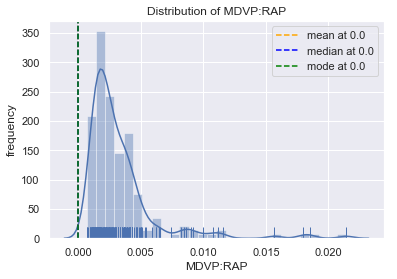

In [64]:
sns.distplot(df_org['MDVP:RAP'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:RAP")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:RAP")
measurements = [round(df_org['MDVP:RAP'].mean(),2), round(df_org['MDVP:RAP'].median(),2), round(df_org['MDVP:RAP'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:RAP' data seems to be slightly right skewed with few outliers. Also, it seems there are many zeros in the records 


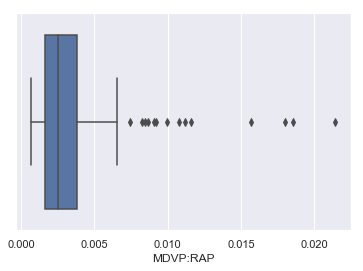

In [65]:
sns.boxplot(df_org['MDVP:RAP']);
b("Column 'MDVP:RAP' data seems to be slightly right skewed with few outliers. Also, it seems there are many zeros in the records")

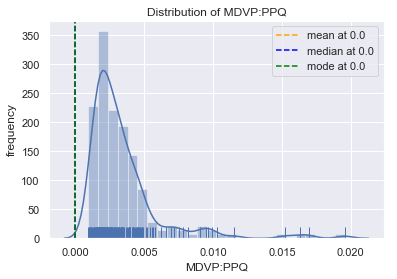

In [66]:
sns.distplot(df_org['MDVP:PPQ'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:PPQ")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:PPQ")
measurements = [round(df_org['MDVP:PPQ'].mean(),2), round(df_org['MDVP:PPQ'].median(),2), round(df_org['MDVP:PPQ'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:PPQ' data seems to be slightly right skewed with few outliers 


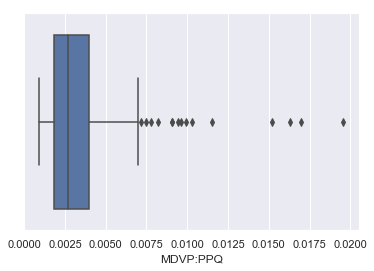

In [67]:
sns.boxplot(df_org['MDVP:PPQ']);
b("Column 'MDVP:PPQ' data seems to be slightly right skewed with few outliers")

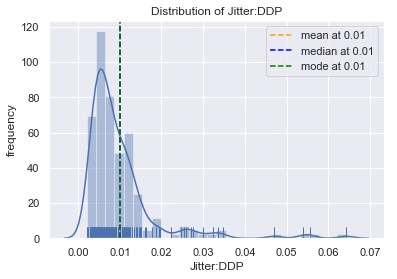

In [68]:
sns.distplot(df_org['Jitter:DDP'],hist=True, kde=True, rug=True);
plt.xlabel("Jitter:DDP")
plt.ylabel("frequency")
plt.title(f"Distribution of Jitter:DDP")
measurements = [round(df_org['Jitter:DDP'].mean(),2), round(df_org['Jitter:DDP'].median(),2), round(df_org['Jitter:DDP'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'Jitter:DDP' data seems to be right skewed with few outliers 


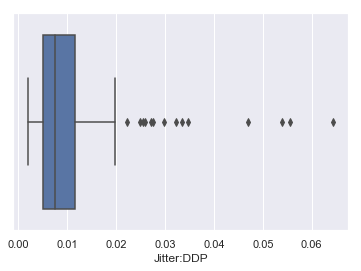

In [69]:
sns.boxplot(df_org['Jitter:DDP']);
b("Column 'Jitter:DDP' data seems to be right skewed with few outliers")

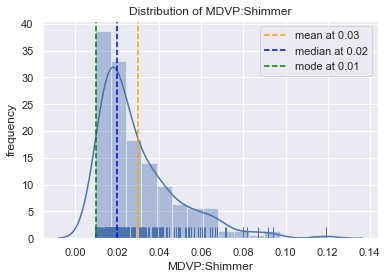

In [70]:
sns.distplot(df_org['MDVP:Shimmer'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:Shimmer")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:Shimmer")
measurements = [round(df_org['MDVP:Shimmer'].mean(),2), round(df_org['MDVP:Shimmer'].median(),2), round(df_org['MDVP:Shimmer'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:Shimmer' data seems to be right skewed with few outliers 


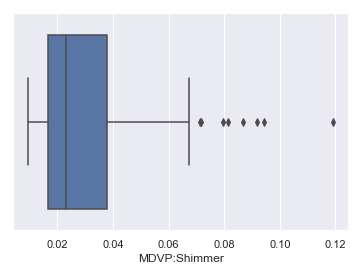

In [71]:
sns.boxplot(df_org['MDVP:Shimmer']);
b("Column 'MDVP:Shimmer' data seems to be right skewed with few outliers")

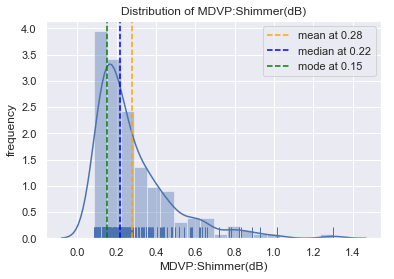

In [72]:
sns.distplot(df_org['MDVP:Shimmer(dB)'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:Shimmer(dB)")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:Shimmer(dB)")
measurements = [round(df_org['MDVP:Shimmer(dB)'].mean(),2), round(df_org['MDVP:Shimmer(dB)'].median(),2), round(df_org['MDVP:Shimmer(dB)'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:Shimmer(dB)' data seems to be right skewed with few outliers 


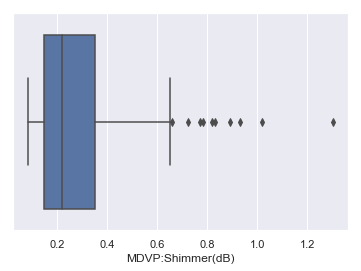

In [73]:
sns.boxplot(df_org['MDVP:Shimmer(dB)']);
b("Column 'MDVP:Shimmer(dB)' data seems to be right skewed with few outliers")

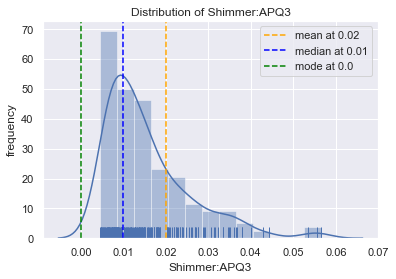

In [74]:
sns.distplot(df_org['Shimmer:APQ3'],hist=True, kde=True, rug=True);
plt.xlabel("Shimmer:APQ3")
plt.ylabel("frequency")
plt.title(f"Distribution of Shimmer:APQ3")
measurements = [round(df_org['Shimmer:APQ3'].mean(),2), round(df_org['Shimmer:APQ3'].median(),2), round(df_org['Shimmer:APQ3'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'Shimmer:APQ3' data seems to be right skewed with few outliers 


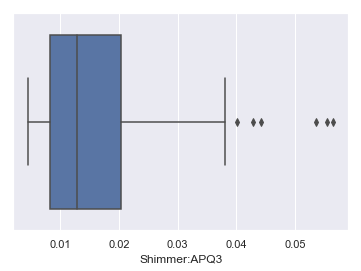

In [75]:
sns.boxplot(df_org['Shimmer:APQ3']);
b("Column 'Shimmer:APQ3' data seems to be right skewed with few outliers")

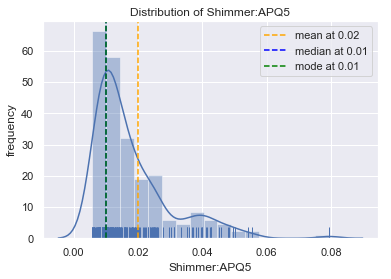

In [76]:
sns.distplot(df_org['Shimmer:APQ5'],hist=True, kde=True, rug=True);
plt.xlabel("Shimmer:APQ5")
plt.ylabel("frequency")
plt.title(f"Distribution of Shimmer:APQ5")
measurements = [round(df_org['Shimmer:APQ5'].mean(),2), round(df_org['Shimmer:APQ5'].median(),2), round(df_org['Shimmer:APQ5'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'Shimmer:APQ5' data seems to be right skewed with few outliers 


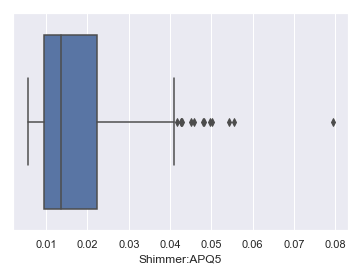

In [77]:
sns.boxplot(df_org['Shimmer:APQ5']);
b("Column 'Shimmer:APQ5' data seems to be right skewed with few outliers")

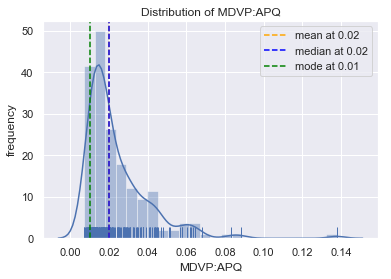

In [78]:
sns.distplot(df_org['MDVP:APQ'],hist=True, kde=True, rug=True);
plt.xlabel("MDVP:APQ")
plt.ylabel("frequency")
plt.title(f"Distribution of MDVP:APQ")
measurements = [round(df_org['MDVP:APQ'].mean(),2), round(df_org['MDVP:APQ'].median(),2), round(df_org['MDVP:APQ'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'MDVP:APQ' data seems to be slightly right skewed with few outliers 


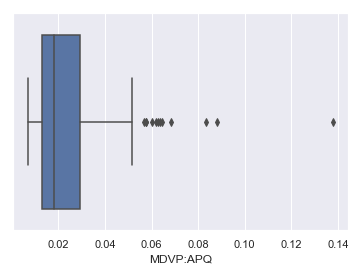

In [79]:
sns.boxplot(df_org['MDVP:APQ']);
b("Column 'MDVP:APQ' data seems to be slightly right skewed with few outliers")

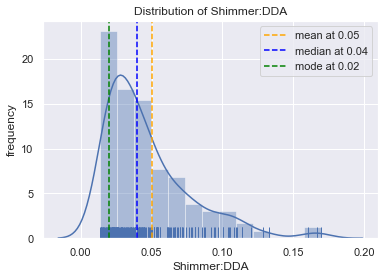

In [80]:
sns.distplot(df_org['Shimmer:DDA'],hist=True, kde=True, rug=True);
plt.xlabel("Shimmer:DDA")
plt.ylabel("frequency")
plt.title(f"Distribution of Shimmer:DDA")
measurements = [round(df_org['Shimmer:DDA'].mean(),2), round(df_org['Shimmer:DDA'].median(),2), round(df_org['Shimmer:DDA'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'Shimmer:DDA' data seems to be right skewed with few outliers 


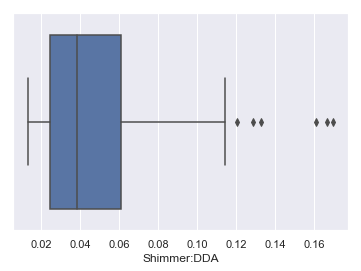

In [81]:
sns.boxplot(df_org['Shimmer:DDA']);
b("Column 'Shimmer:DDA' data seems to be right skewed with few outliers")

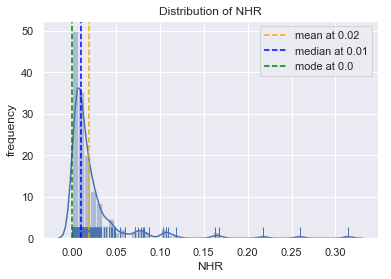

In [82]:
sns.distplot(df_org['NHR'],hist=True, kde=True, rug=True);
plt.xlabel("NHR")
plt.ylabel("frequency")
plt.title(f"Distribution of NHR")
measurements = [round(df_org['NHR'].mean(),2), round(df_org['NHR'].median(),2), round(df_org['NHR'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'NHR' data seems to be right skewed with few outliers 


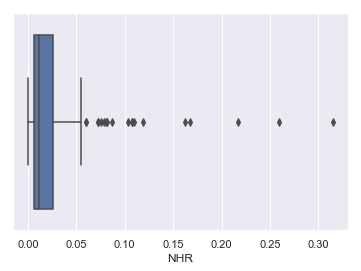

In [83]:
sns.boxplot(df_org['NHR']);
b("Column 'NHR' data seems to be right skewed with few outliers")

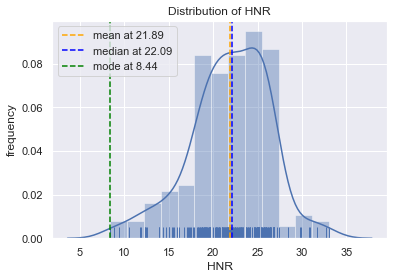

In [84]:
sns.distplot(df_org['HNR'],hist=True, kde=True, rug=True);
plt.xlabel("HNR")
plt.ylabel("frequency")
plt.title(f"Distribution of HNR")
measurements = [round(df_org['HNR'].mean(),2), round(df_org['HNR'].median(),2), round(df_org['HNR'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'HNR' data seems to be approximately normalled distributed with very few outliers 


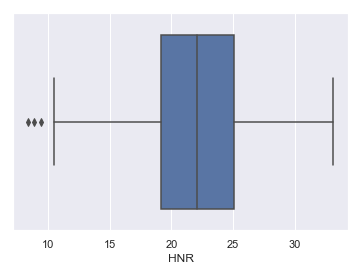

In [85]:
sns.boxplot(df_org['HNR']);
b("Column 'HNR' data seems to be approximately normalled distributed with very few outliers")

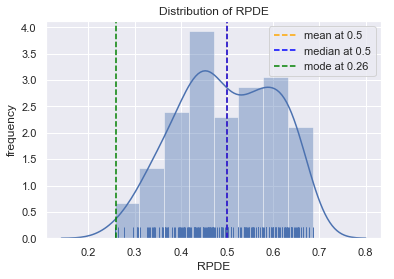

In [86]:
sns.distplot(df_org['RPDE'],hist=True, kde=True, rug=True);
plt.xlabel("RPDE")
plt.ylabel("frequency")
plt.title(f"Distribution of RPDE")
measurements = [round(df_org['RPDE'].mean(),2), round(df_org['RPDE'].median(),2), round(df_org['RPDE'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'RPDE' data seems to be left skewed without any outliers 


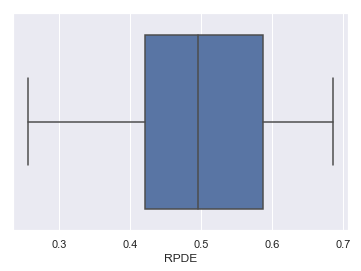

In [87]:
sns.boxplot(df_org['RPDE']);
b("Column 'RPDE' data seems to be left skewed without any outliers")

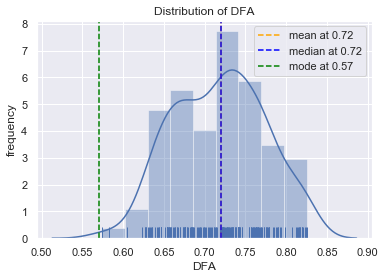

In [88]:
sns.distplot(df_org['DFA'],hist=True, kde=True, rug=True);
plt.xlabel("DFA")
plt.ylabel("frequency")
plt.title(f"Distribution of DFA")
measurements = [round(df_org['DFA'].mean(),2), round(df_org['DFA'].median(),2), round(df_org['DFA'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'DFA' data seems to be left skewed without any outliers 


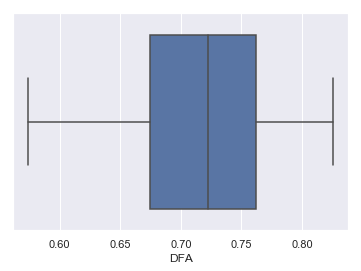

In [89]:
sns.boxplot(df_org['DFA']);
b("Column 'DFA' data seems to be left skewed without any outliers")

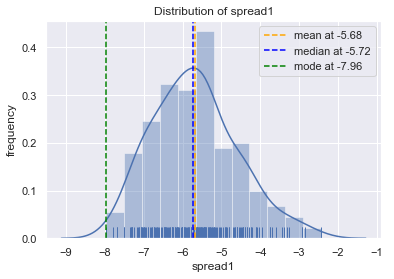

In [90]:
sns.distplot(df_org['spread1'],hist=True, kde=True, rug=True);
plt.xlabel("spread1")
plt.ylabel("frequency")
plt.title(f"Distribution of spread1")
measurements = [round(df_org['spread1'].mean(),2), round(df_org['spread1'].median(),2), round(df_org['spread1'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'spread1' data seems to be normally distributed with few outliers on the upper side 


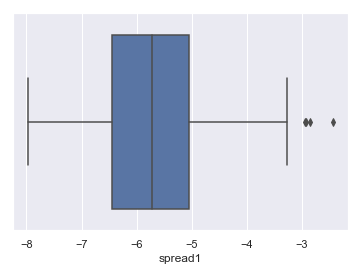

In [91]:
sns.boxplot(df_org['spread1']);
b("Column 'spread1' data seems to be normally distributed with few outliers on the upper side")

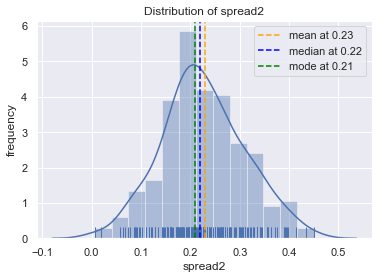

In [92]:
sns.distplot(df_org['spread2'],hist=True, kde=True, rug=True);
plt.xlabel("spread2")
plt.ylabel("frequency")
plt.title(f"Distribution of spread2")
measurements = [round(df_org['spread2'].mean(),2), round(df_org['spread2'].median(),2), round(df_org['spread2'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'spread2' data seems to be normally distributed with very few outliers on both the sides 


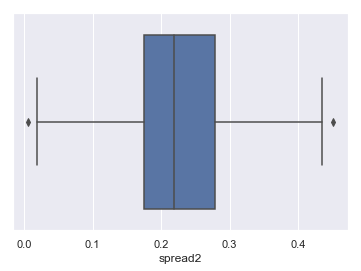

In [93]:
sns.boxplot(df_org['spread2']);
b("Column 'spread2' data seems to be normally distributed with very few outliers on both the sides")

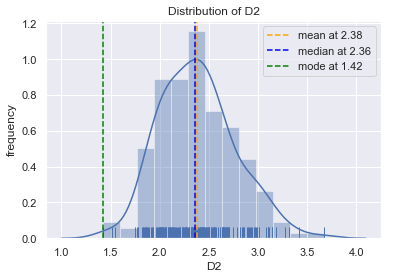

In [94]:
sns.distplot(df_org['D2'],hist=True, kde=True, rug=True);
plt.xlabel("D2")
plt.ylabel("frequency")
plt.title(f"Distribution of D2")
measurements = [round(df_org['D2'].mean(),2), round(df_org['D2'].median(),2), round(df_org['D2'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'D2' data seems to be normally distributed with few outliers on the upper side 


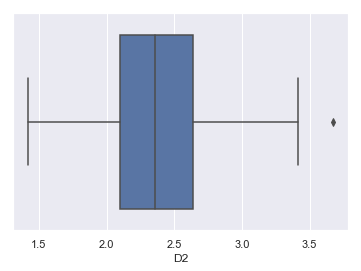

In [95]:
sns.boxplot(df_org['D2']);
b("Column 'D2' data seems to be normally distributed with few outliers on the upper side")

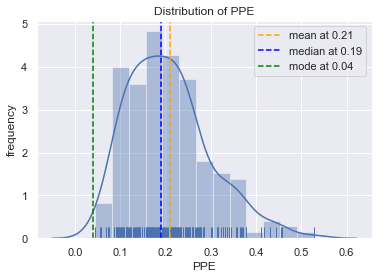

In [96]:
sns.distplot(df_org['PPE'],hist=True, kde=True, rug=True);
plt.xlabel("PPE")
plt.ylabel("frequency")
plt.title(f"Distribution of PPE")
measurements = [round(df_org['PPE'].mean(),2), round(df_org['PPE'].median(),2), round(df_org['PPE'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'PPE' data seems to be nearly right skewed with few outliers on the upper boundary 


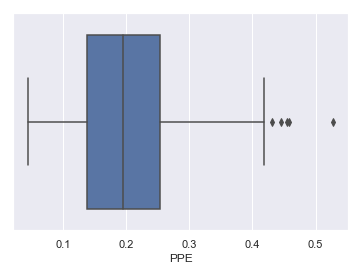

In [97]:
sns.boxplot(df_org['PPE']);
b("Column 'PPE' data seems to be nearly right skewed with few outliers on the upper boundary")

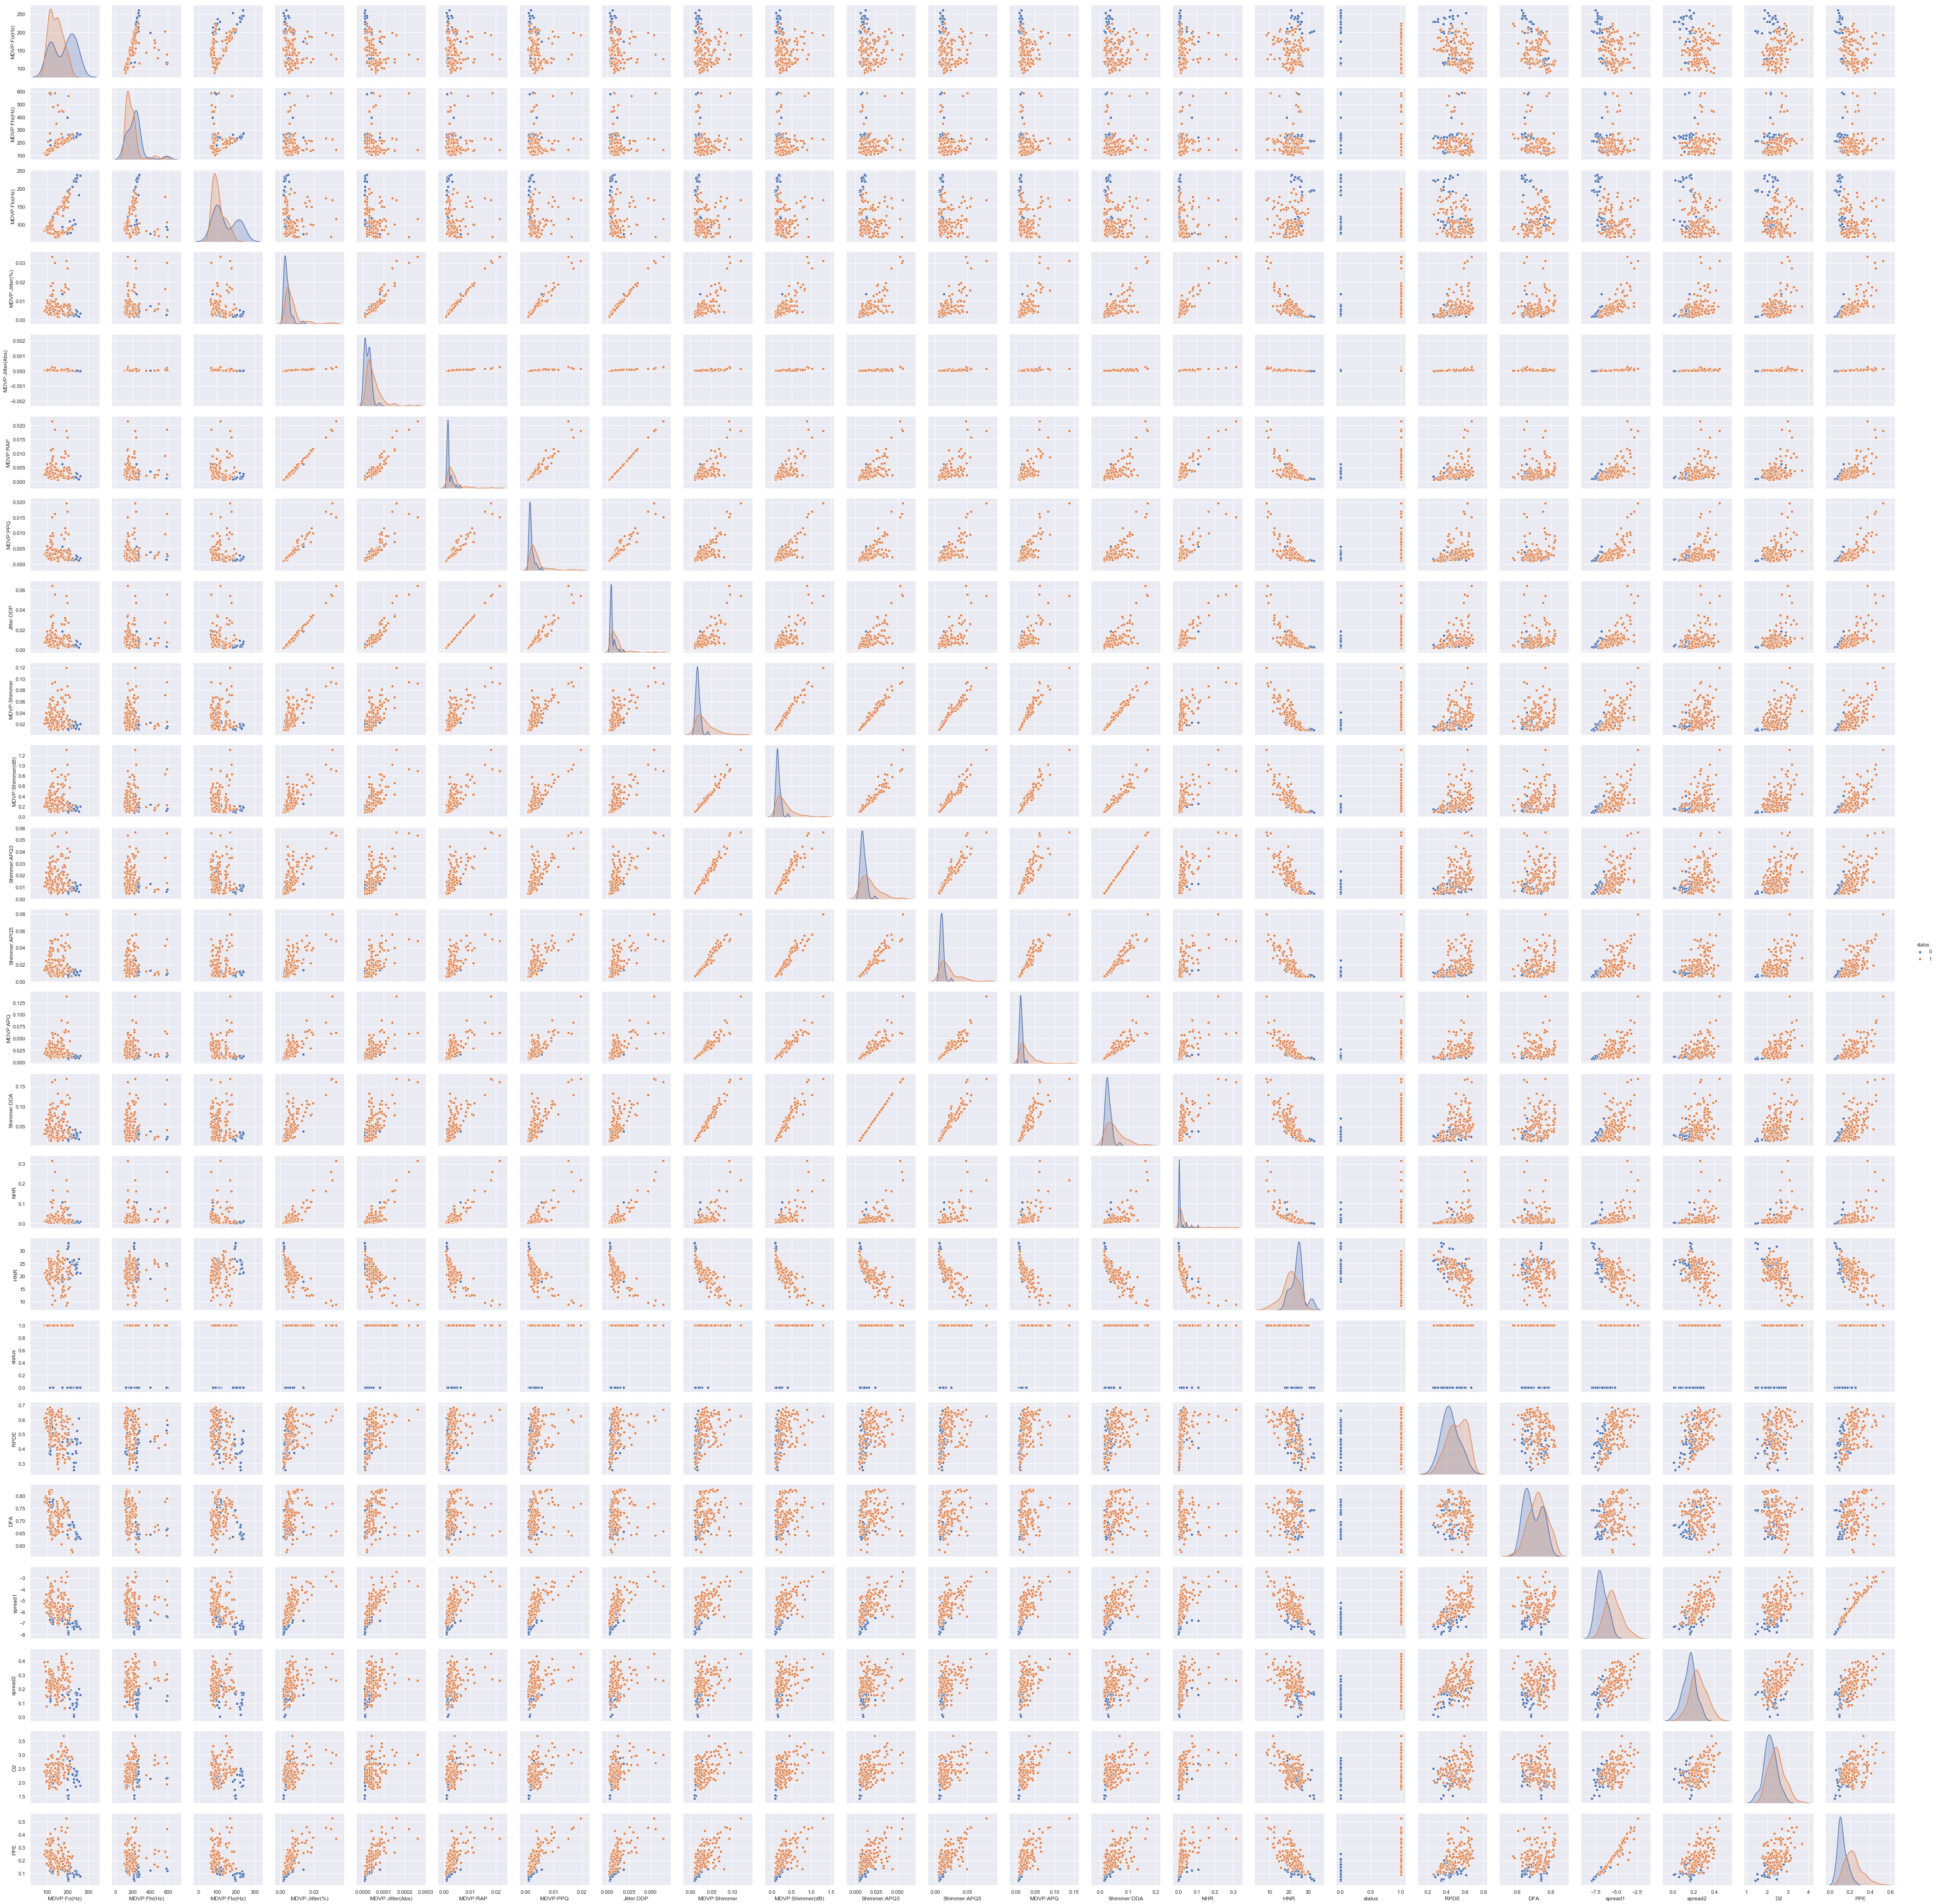

In [98]:
sns.pairplot(df_org, height=2.5, diag_kind='kde', hue='status')

In [99]:
b("1. There are positively and negatively correlated columns in the dataset.\n 2. There are attributes with right skewness, left skewness, normal distribution in the dataset.\n 3. There are outliers in most of the attributes.\n 4. I'm going to approach the model training and testing after data normalization without removing outliers as there are only very limited observation points provided. ")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 1. There are positively and negatively correlated columns in the dataset.
 2. There are attributes with right skewness, left skewness, normal distribution in the dataset.
 3. There are outliers in most of the attributes.
 4. I'm going to approach the model training and testing after data normalization without removing outliers as there are only very limited observation points provided.  


## 4. Split the dataset into training and test set in the ratio of 70:30 (Training:Test)

## 5. Prepare the data for training - Scale the data if necessary, get rid of missing values (if any) etc

In [100]:
X = df_org[['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP','MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5','MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA','spread1', 'spread2', 'D2', 'PPE']].copy()

In [101]:
y=df_org[['status']].copy()

In [102]:
X = X.rename(columns={'MDVP:Fo(Hz)':'MDVP_Fo_Hz', 'MDVP:Fhi(Hz)':'MDVP_Fhi_Hz','MDVP:Flo(Hz)':'MDVP_Flo_Hz', 'MDVP:Jitter(%)':'MDVP_Jitter_percentage', 'MDVP:Jitter(Abs)':'MDVP_Jitter_Abs', 'MDVP:RAP':'MDVP_RAP', 'MDVP:PPQ':'MDVP_PPQ', 'Jitter:DDP':'Jitter_DDP', 'MDVP:Shimmer':'MDVP_Shimmer', 'MDVP:Shimmer(dB)':'MDVP_Shimmer_dB', 'Shimmer:APQ3':'Shimmer_APQ3', 'Shimmer:APQ5':'Shimmer_APQ5', 'MDVP:APQ':'MDVP_APQ', 'Shimmer:DDA':'Shimmer_DDA'})
X.columns

Index(['MDVP_Fo_Hz', 'MDVP_Fhi_Hz', 'MDVP_Flo_Hz', 'MDVP_Jitter_percentage',
       'MDVP_Jitter_Abs', 'MDVP_RAP', 'MDVP_PPQ', 'Jitter_DDP', 'MDVP_Shimmer',
       'MDVP_Shimmer_dB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'MDVP_APQ',
       'Shimmer_DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2',
       'PPE'],
      dtype='object')

In [103]:
y.columns

Index(['status'], dtype='object')

In [104]:
#Split the data into training and test set in the ratio of 70:30 respectively
from sklearn import preprocessing

random_st = 21
stratify_ind = None
#Without scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# MinMax Normalization
min_max_scaler = preprocessing.MinMaxScaler()
X_minmax = pd.DataFrame(min_max_scaler.fit_transform(X))
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X_minmax, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# Standard Normalization
std_scaler = preprocessing.StandardScaler()
X_std = pd.DataFrame(std_scaler.fit_transform(X))
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# Robust Normalization as there are multiple outliers in the dataset
robust_scaler = preprocessing.RobustScaler()
X_robust = pd.DataFrame(robust_scaler.fit_transform(X))
X_train_robust, X_test_robust, y_train_robust, y_test_robust = train_test_split(X_robust, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

scaling_types = ['No Scaler', 'MinMax Scaler','Standared Normal Scaler', 'Robust Scaler']
X_train_norms, X_test_norms = [[X_train, X_train_minmax, X_train_std, X_train_robust],[X_test, X_test_minmax, X_test_std, X_test_robust]]
y_train_norms, y_test_norms = [[y_train, y_train_minmax, y_train_std, y_train_robust],[y_test, y_test_minmax, y_test_std, y_test_robust]]

## 6. Train at least 3 standard classification algorithms - Logistic Regression, Naive Bayes’, SVM, k-NN etc, and note down their accuracies on the test data

Logistic Regression - Training Score on No Scaler dataset is 0.8455882352941176
Logistic Regression - Test Score on No Scaler dataset is 0.9152542372881356
No Scaler - Logistic Regression - liblinear - Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.67      0.76        12
           0       0.92      0.98      0.95        47

    accuracy                           0.92        59
   macro avg       0.90      0.82      0.86        59
weighted avg       0.91      0.92      0.91        59

Logistic Regression - Training Score on No Scaler dataset is 0.8235294117647058
Logistic Regression - Test Score on No Scaler dataset is 0.9322033898305084
No Scaler - Logistic Regression - lbfgs - Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.75      0.82        12
           0       0.94      0.98      0.96        47

    accuracy                           0.93        59
   macro 

Logistic Regression - Training Score on Robust Scaler dataset is 0.8455882352941176
Logistic Regression - Test Score on Robust Scaler dataset is 0.9491525423728814
Robust Scaler - Logistic Regression - lbfgs - Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.83      0.87        12
           0       0.96      0.98      0.97        47

    accuracy                           0.95        59
   macro avg       0.93      0.91      0.92        59
weighted avg       0.95      0.95      0.95        59

Logistic Regression - Training Score on Robust Scaler dataset is 0.8455882352941176
Logistic Regression - Test Score on Robust Scaler dataset is 0.9491525423728814
Robust Scaler - Logistic Regression - newton-cg - Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.83      0.87        12
           0       0.96      0.98      0.97        47

    accuracy                           

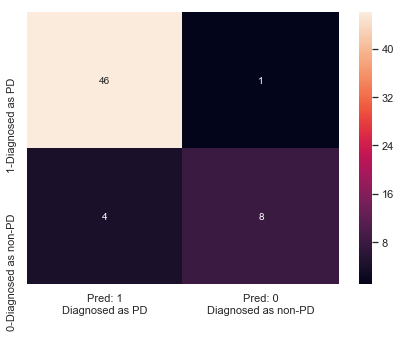

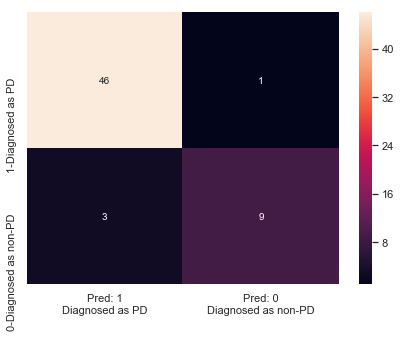

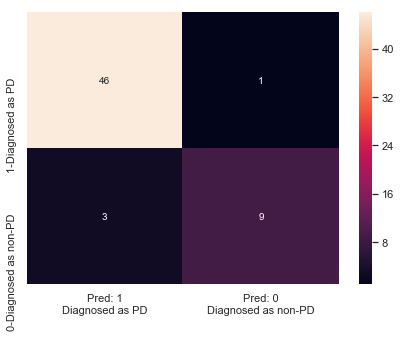

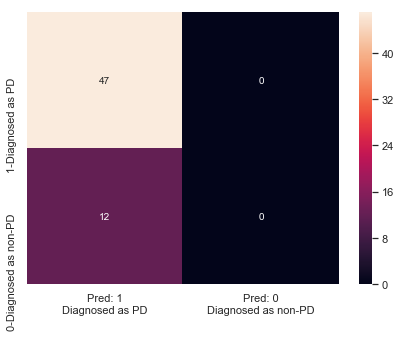

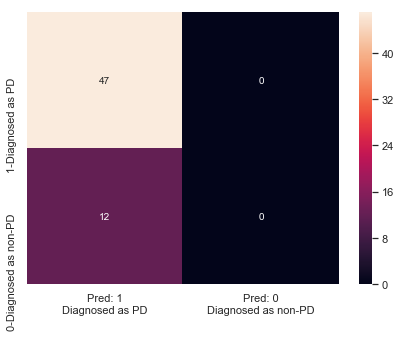

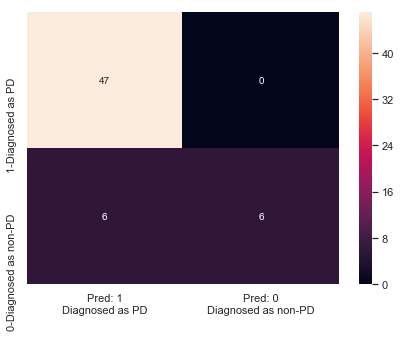

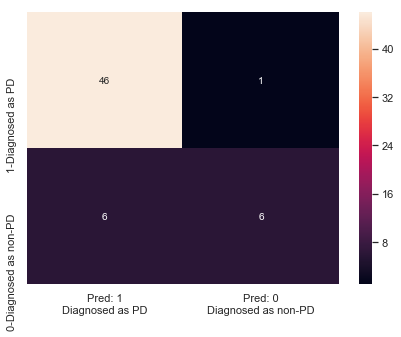

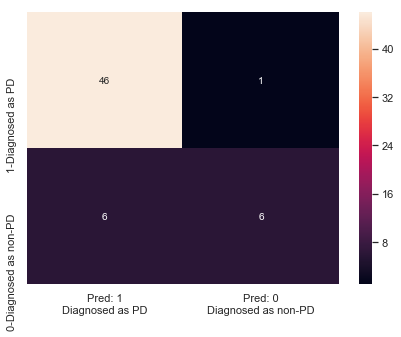

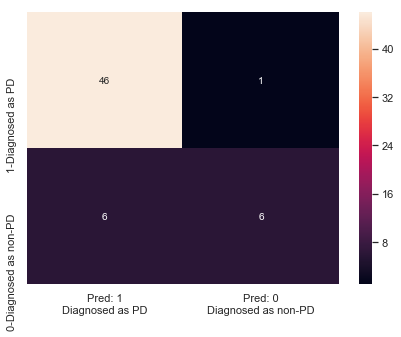

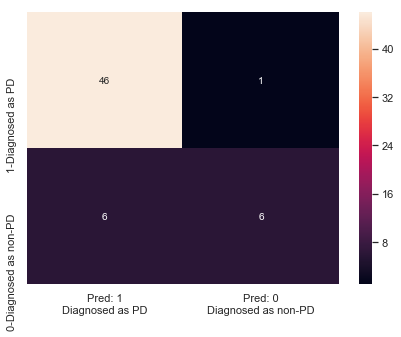

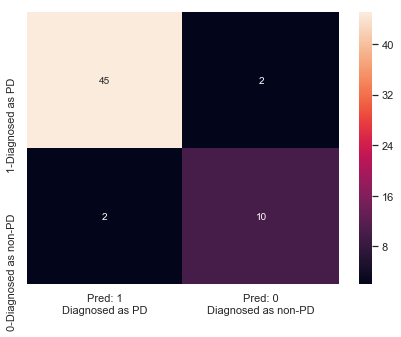

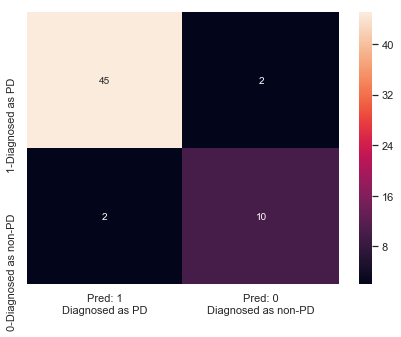

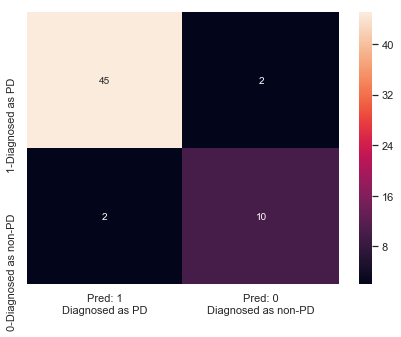

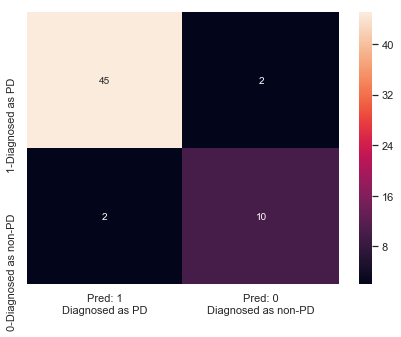

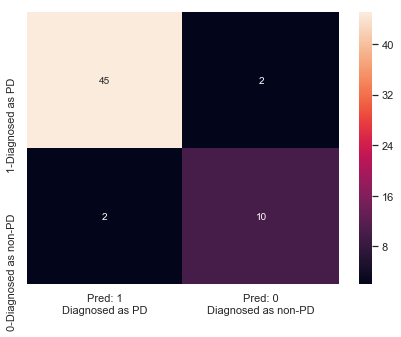

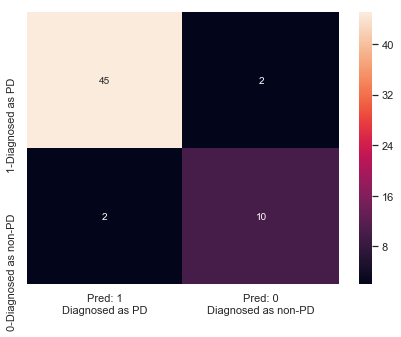

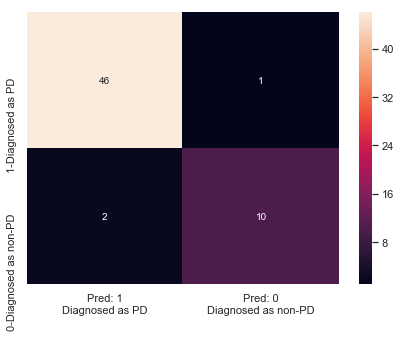

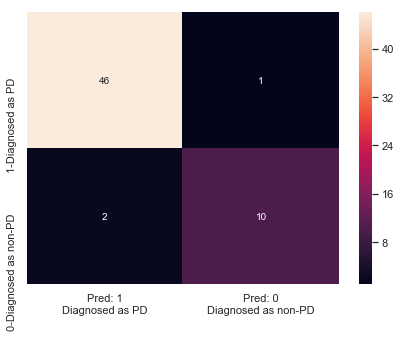

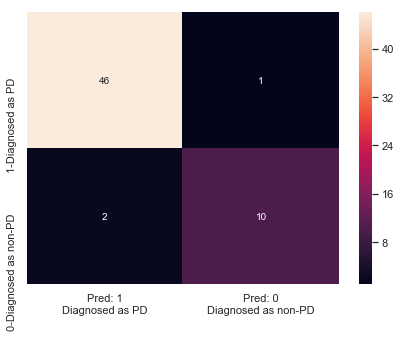

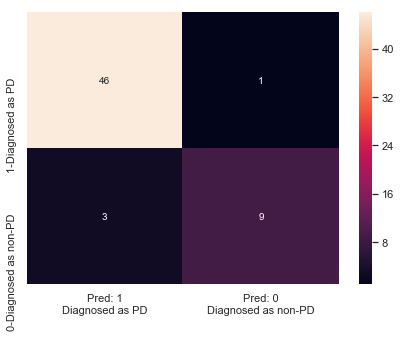

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics

model_names = []
model_scores = []
fin_model_names =[]
fin_model_scores = []

# 1. Logistic Regression - Classifier
solvers = ['liblinear', 'lbfgs','newton-cg','sag', 'saga']
algo_name = "Logistic Regression"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
    for solver_name in solvers:
        clf = LogisticRegression(solver=solver_name)
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - {3} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values)), solver_name))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2} - {3} - {4}".format(algo_name, solver_name, solver_name, scaler_type, pred_score))
        model_scores.append(pred_score)

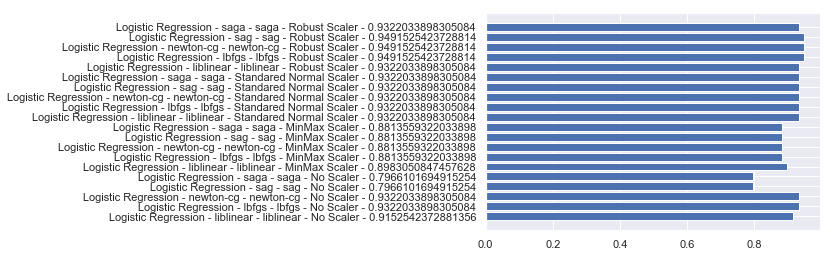

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 I see that there is an underfitting in the model, however i'm choosing the combination that gives highest prediction considering f1 score of both the classes 


In [106]:
plt.barh(model_names, model_scores)
plt.show()
b("I see that there is an underfitting in the model, however i'm choosing the combination that gives highest prediction considering f1 score of both the classes")
fin_model_names.append("Robust Scaler - Logistic Regression - lbfgs")
fin_model_scores.append(0.9491525423728814)

KNN - Training Score on No Scaler dataset is 1.0
KNN - Test Score on No Scaler dataset is 0.847457627118644
No Scaler - KNN - Classification Report:
              precision    recall  f1-score   support

           1       0.64      0.58      0.61        12
           0       0.90      0.91      0.91        47

    accuracy                           0.85        59
   macro avg       0.77      0.75      0.76        59
weighted avg       0.84      0.85      0.84        59

KNN - Training Score on MinMax Scaler dataset is 1.0
KNN - Test Score on MinMax Scaler dataset is 0.9491525423728814
MinMax Scaler - KNN - Classification Report:
              precision    recall  f1-score   support

           1       0.80      1.00      0.89        12
           0       1.00      0.94      0.97        47

    accuracy                           0.95        59
   macro avg       0.90      0.97      0.93        59
weighted avg       0.96      0.95      0.95        59

KNN - Training Score on Standared N

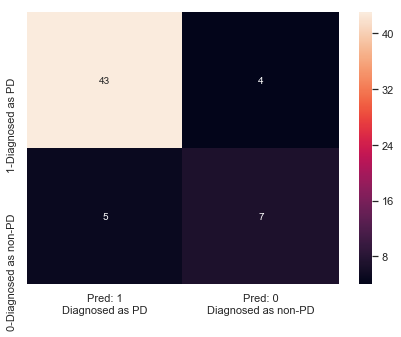

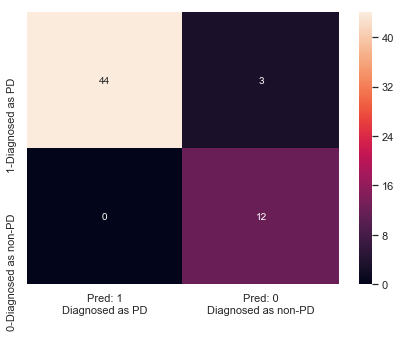

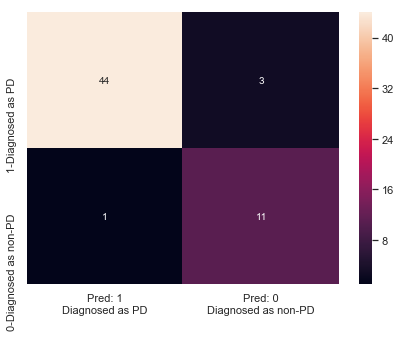

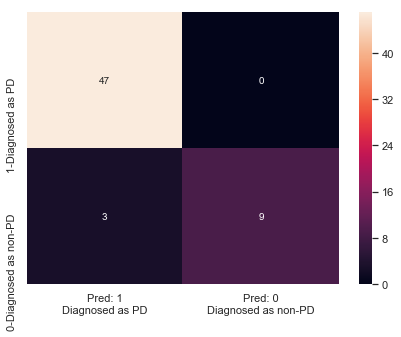

In [107]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

model_names = []
model_scores = []
algo_name = "KNN"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
        clf = KNeighborsClassifier(n_neighbors=3, weights='distance', leaf_size=15)
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

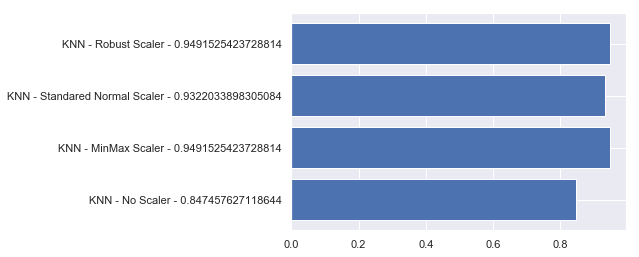

In [108]:
plt.barh(model_names, model_scores)
plt.show()

In [109]:
b("I see that there is an overfitting in the model, however i'm choosing the combination that gives highest prediction considering f1 score of both the classes")
fin_model_names.append("MinMax Scaler - KNN")
fin_model_scores.append(0.9491525423728814)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 I see that there is an overfitting in the model, however i'm choosing the combination that gives highest prediction considering f1 score of both the classes 


SVC - Training Score on No Scaler dataset is 0.8455882352941176
SVC - Test Score on No Scaler dataset is 0.9491525423728814
No Scaler - SVC - linear - Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.83      0.87        12
           0       0.96      0.98      0.97        47

    accuracy                           0.95        59
   macro avg       0.93      0.91      0.92        59
weighted avg       0.95      0.95      0.95        59

SVC - Training Score on No Scaler dataset is 0.7941176470588235
SVC - Test Score on No Scaler dataset is 0.8813559322033898
No Scaler - SVC - poly - Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.42      0.59        12
           0       0.87      1.00      0.93        47

    accuracy                           0.88        59
   macro avg       0.94      0.71      0.76        59
weighted avg       0.90      0.88      0.86        59



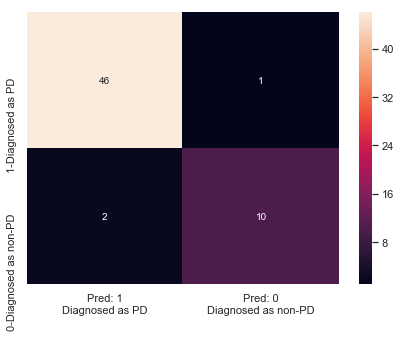

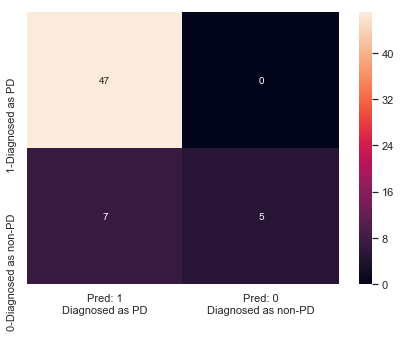

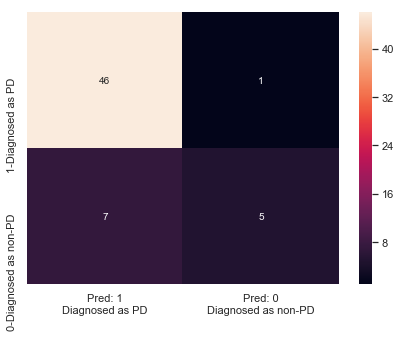

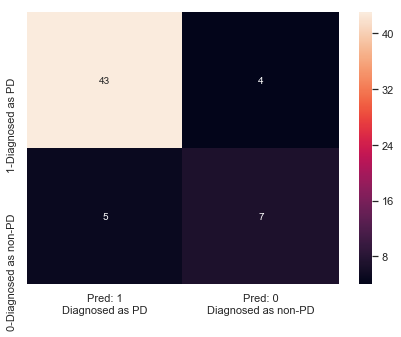

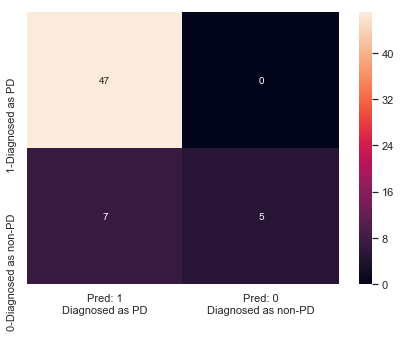

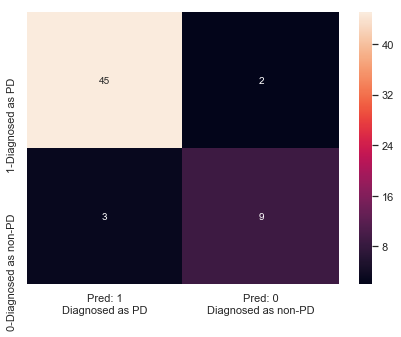

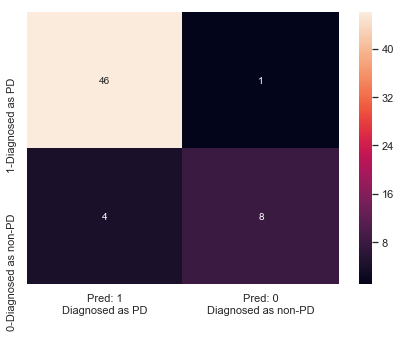

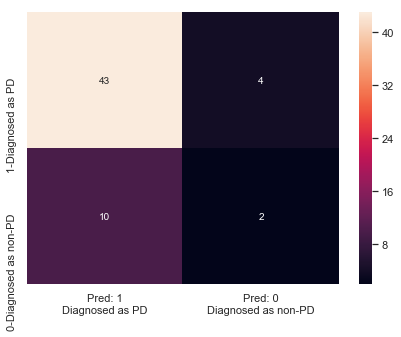

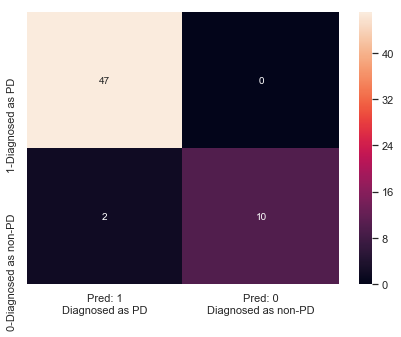

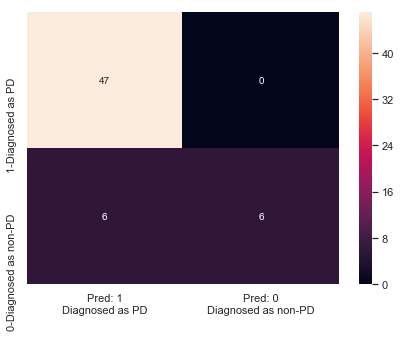

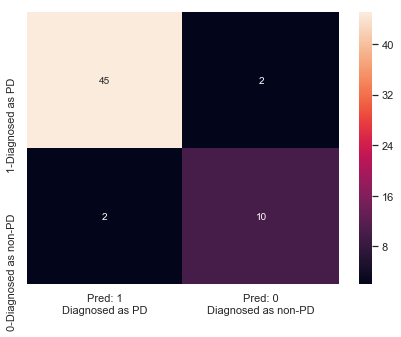

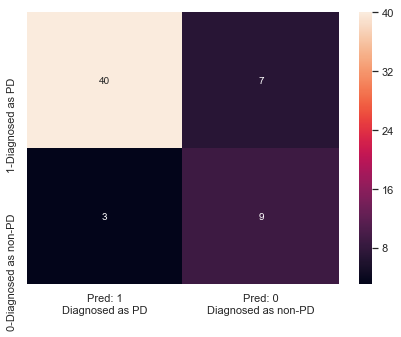

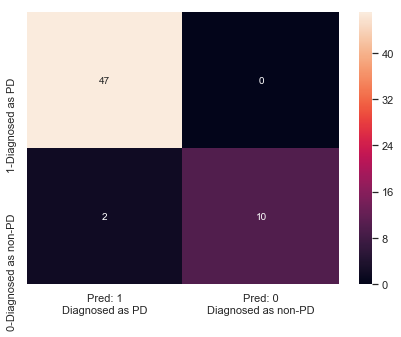

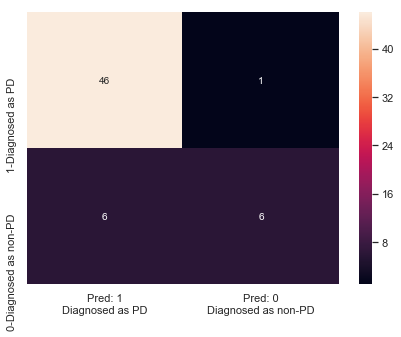

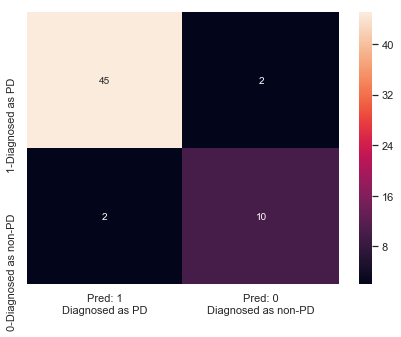

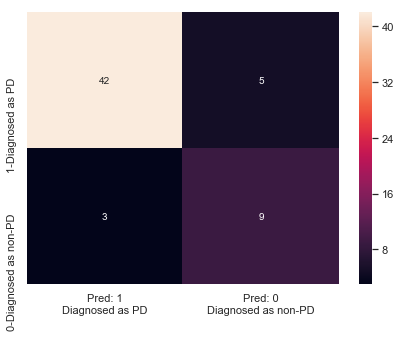

In [110]:
from sklearn.svm import SVC
model_names = []
model_scores = []

# 1. SV - Classifier
#solvers = ['sigmoid']
solvers = ['linear', 'poly', 'rbf', 'sigmoid']
algo_name = "SVC"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
    for solver_name in solvers:
        clf = SVC(C=1.1, tol=1.25, gamma='scale', kernel=solver_name)
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - {3} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values)), solver_name))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2} - {3} - {4}".format(algo_name, solver_name, solver_name, scaler_type, pred_score))
        model_scores.append(pred_score)

In [111]:
model_names

['SVC - linear - linear - No Scaler - 0.9491525423728814',
 'SVC - poly - poly - No Scaler - 0.8813559322033898',
 'SVC - rbf - rbf - No Scaler - 0.864406779661017',
 'SVC - sigmoid - sigmoid - No Scaler - 0.847457627118644',
 'SVC - linear - linear - MinMax Scaler - 0.8813559322033898',
 'SVC - poly - poly - MinMax Scaler - 0.9152542372881356',
 'SVC - rbf - rbf - MinMax Scaler - 0.9152542372881356',
 'SVC - sigmoid - sigmoid - MinMax Scaler - 0.7627118644067796',
 'SVC - linear - linear - Standared Normal Scaler - 0.9661016949152542',
 'SVC - poly - poly - Standared Normal Scaler - 0.8983050847457628',
 'SVC - rbf - rbf - Standared Normal Scaler - 0.9322033898305084',
 'SVC - sigmoid - sigmoid - Standared Normal Scaler - 0.8305084745762712',
 'SVC - linear - linear - Robust Scaler - 0.9661016949152542',
 'SVC - poly - poly - Robust Scaler - 0.8813559322033898',
 'SVC - rbf - rbf - Robust Scaler - 0.9322033898305084',
 'SVC - sigmoid - sigmoid - Robust Scaler - 0.864406779661017']

In [112]:
model_scores

[0.9491525423728814,
 0.8813559322033898,
 0.864406779661017,
 0.847457627118644,
 0.8813559322033898,
 0.9152542372881356,
 0.9152542372881356,
 0.7627118644067796,
 0.9661016949152542,
 0.8983050847457628,
 0.9322033898305084,
 0.8305084745762712,
 0.9661016949152542,
 0.8813559322033898,
 0.9322033898305084,
 0.864406779661017]

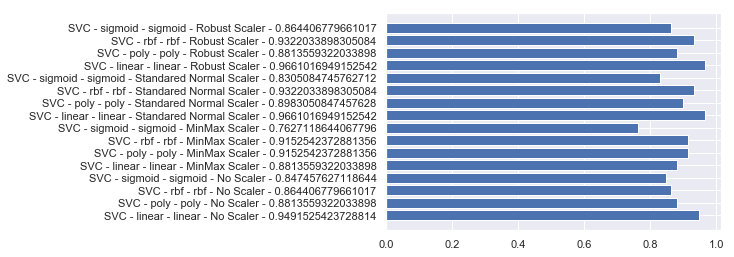

In [113]:
plt.barh(model_names, model_scores)
plt.show()

In [114]:
b("I see that there is an underfitting in the model, however i'm choosing the combination that gives highest prediction considering f1 score of both the classes")
fin_model_names.append("Robust Scaler - SVC - linear")
fin_model_scores.append(0.9661016949152542)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 I see that there is an underfitting in the model, however i'm choosing the combination that gives highest prediction considering f1 score of both the classes 


Naive Bayes - Gaussian - Training Score on No Scaler dataset is 0.8235294117647058
Naive Bayes - Gaussian - Test Score on No Scaler dataset is 0.864406779661017
No Scaler - Naive Bayes - Gaussian - Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.42      0.56        12
           0       0.87      0.98      0.92        47

    accuracy                           0.86        59
   macro avg       0.85      0.70      0.74        59
weighted avg       0.86      0.86      0.85        59

Naive Bayes - Gaussian - Training Score on MinMax Scaler dataset is 0.6985294117647058
Naive Bayes - Gaussian - Test Score on MinMax Scaler dataset is 0.6779661016949152
MinMax Scaler - Naive Bayes - Gaussian - Classification Report:
              precision    recall  f1-score   support

           1       0.38      0.92      0.54        12
           0       0.97      0.62      0.75        47

    accuracy                           0.68        59


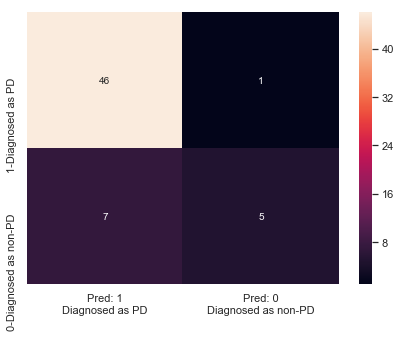

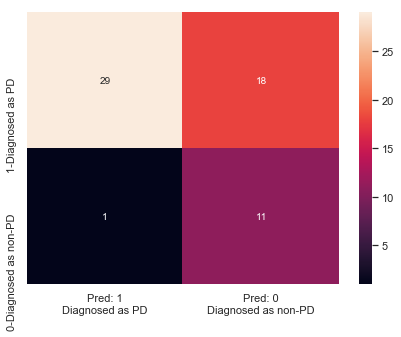

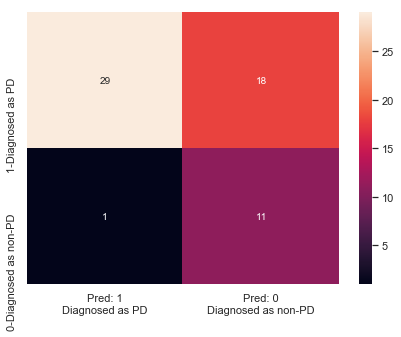

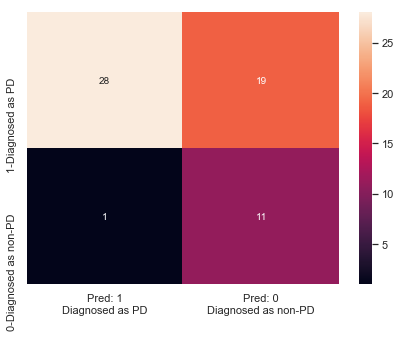

In [117]:
#NB
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB, ComplementNB

model_names = []
model_scores = []
algo_name = "Naive Bayes - Gaussian"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
        clf = GaussianNB(var_smoothing=2.0e-01)
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

In [118]:
model_names

['Naive Bayes - Gaussian - No Scaler - 0.864406779661017',
 'Naive Bayes - Gaussian - MinMax Scaler - 0.6779661016949152',
 'Naive Bayes - Gaussian - Standared Normal Scaler - 0.6779661016949152',
 'Naive Bayes - Gaussian - Robust Scaler - 0.6610169491525424']

In [119]:
model_scores

[0.864406779661017, 0.6779661016949152, 0.6779661016949152, 0.6610169491525424]

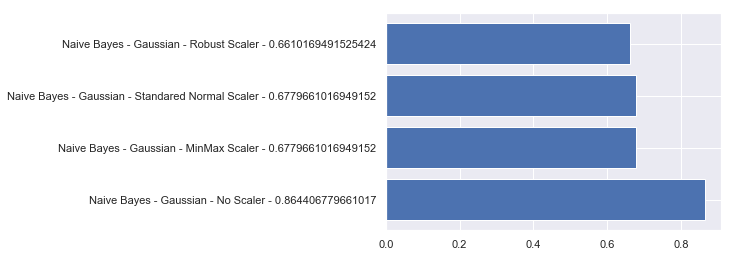

In [120]:
plt.barh(model_names, model_scores)
plt.show()

In [121]:
b("I see that there is an underfitting in the model, however i'm choosing 'Naive Bayes - Gaussian - No Scaler' combination that gives highest prediction considering f1 score of both the classes")
fin_model_names.append("No Scaler - Naive Bayes - Gaussian")
fin_model_scores.append(0.864406779661017)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 I see that there is an underfitting in the model, however i'm choosing 'Naive Bayes - Gaussian - No Scaler' combination that gives highest prediction considering f1 score of both the classes 


In [122]:
fin_model_names

['Robust Scaler - Logistic Regression - lbfgs',
 'MinMax Scaler - KNN',
 'Robust Scaler - SVC - linear',
 'No Scaler - Naive Bayes - Gaussian']

In [123]:
fin_model_scores

[0.9491525423728814, 0.9491525423728814, 0.9661016949152542, 0.864406779661017]

## 7. Train a meta-classifier and note the accuracy on test data

In [124]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier - Training Score on No Scaler dataset is 1.0
Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier - Test Score on No Scaler dataset is 0.864406779661017
No Scaler - Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier - Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.50      0.60        12
           0       0.88      0.96      0.92        47

    accuracy                           0.86        59
   macro avg       0.82      0.73      0.76        59
weighted avg       0.86      0.86      0.85        59

Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier - Training Score on MinMax Scaler dataset is 1.0
Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier - Test Score on MinMax Scaler dataset is 0.9322033898305084
MinMax Scaler - Stacking - KNN, SVC, NB as base-classifiers and LR as me

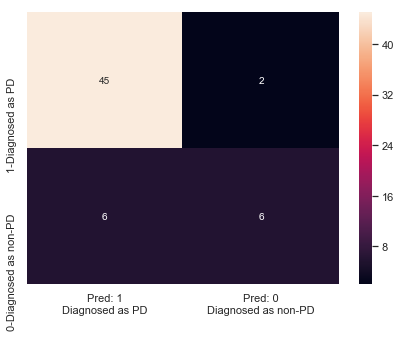

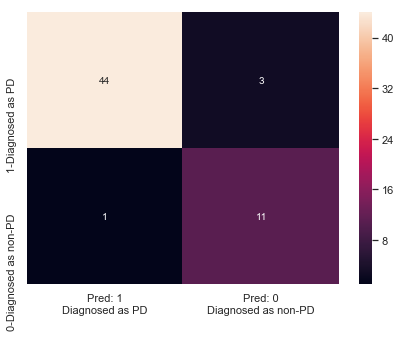

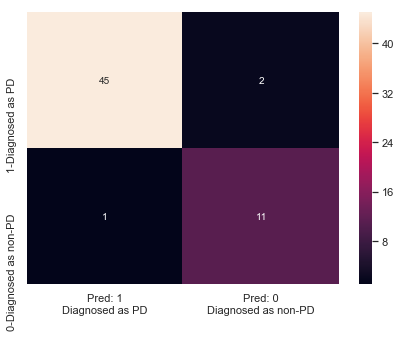

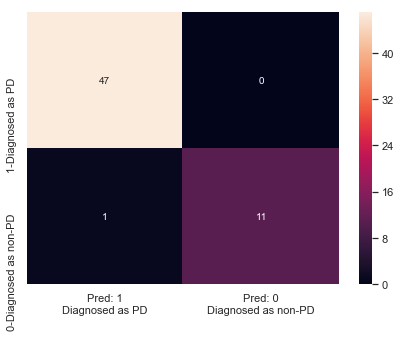

In [125]:
#Stacking model - KNN, SVC, NB as base-classifiers and Logistic Regression as meta-classifier
model_names = []
model_scores = []
algo_name = "Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
        estimators = [('knn', KNeighborsClassifier(n_neighbors=3, weights='distance', leaf_size=30)),('svc', SVC(C=1.1, tol=1.25, gamma='auto', kernel='rbf')),('nb',GaussianNB(var_smoothing=2.0e-01))]
        clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=21, solver='lbfgs', max_iter=50))
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

In [126]:
b("I see that model combination 'Robust Scaler - Stacking - KNN, SVC, NB as base-classifiers and LR as meta -lassifier' is slightly overfitting , however i'm choosing this combination as it gives best prediction considering f1 score of both the classes")
fin_model_names.append("Robust Scaler - Stacking - KNN, SVC, NB as base-classifiers and LR as meta -lassifier")
fin_model_scores.append(0.9830508474576272)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 I see that model combination 'Robust Scaler - Stacking - KNN, SVC, NB as base-classifiers and LR as meta -lassifier' is slightly overfitting , however i'm choosing this combination as it gives best prediction considering f1 score of both the classes 


## 8. Train at least one standard Ensemble model - Random forest, Bagging, Boosting etc, and note the accuracy

Random Forest Classifier - Training Score on No Scaler dataset is 0.9191176470588235
Random Forest Classifier - Test Score on No Scaler dataset is 0.9152542372881356
No Scaler - Random Forest Classifier - Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.75      0.78        12
           0       0.94      0.96      0.95        47

    accuracy                           0.92        59
   macro avg       0.88      0.85      0.86        59
weighted avg       0.91      0.92      0.91        59

Random Forest Classifier - Training Score on MinMax Scaler dataset is 0.9191176470588235
Random Forest Classifier - Test Score on MinMax Scaler dataset is 0.9152542372881356
MinMax Scaler - Random Forest Classifier - Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.75      0.78        12
           0       0.94      0.96      0.95        47

    accuracy                           0.

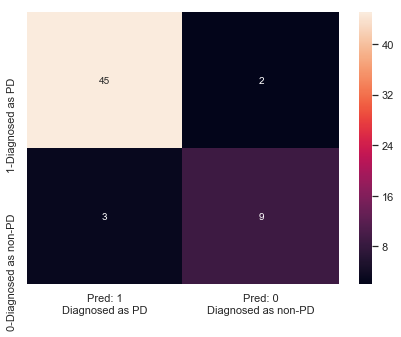

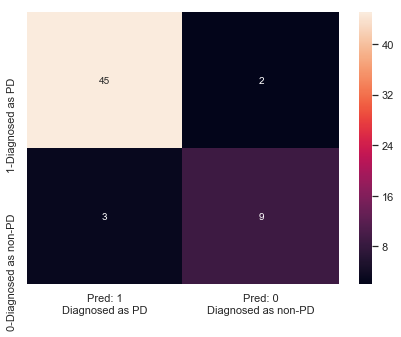

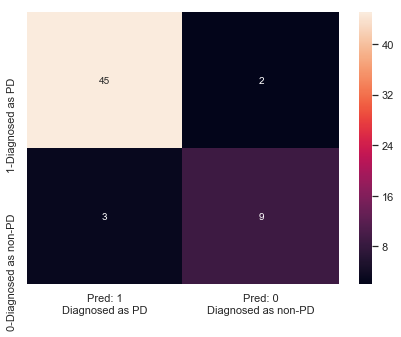

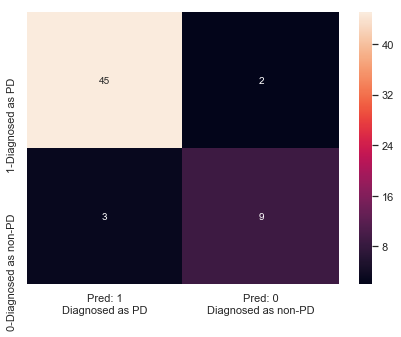

In [127]:
#Ensemble - Bagging - RF
from sklearn.ensemble import RandomForestClassifier
model_names = []
model_scores = []
algo_name = "Random Forest Classifier"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):        
        clf = RandomForestClassifier(n_estimators=4, random_state=21, criterion='entropy', max_depth=3, max_features=16)
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

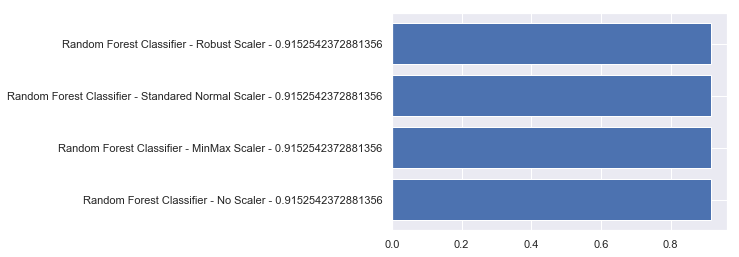

In [128]:
plt.barh(model_names, model_scores)
plt.show()

In [129]:
b("Ensemble - Random Forest classifier is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Random Forest Classifier' as Robust scaler data performs better over others considering different models ouput")
fin_model_names.append("Robust Scaler - Random Forest Classifier")
fin_model_scores.append(0.9152542372881356)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Ensemble - Random Forest classifier is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Random Forest Classifier' as Robust scaler data performs better over others considering different models ouput 


Adaptive Boosting - Training Score on No Scaler dataset is 0.9632352941176471
Adaptive Boosting - Test Score on No Scaler dataset is 0.9491525423728814
No Scaler - Adaptive Boosting - Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.83      0.87        12
           0       0.96      0.98      0.97        47

    accuracy                           0.95        59
   macro avg       0.93      0.91      0.92        59
weighted avg       0.95      0.95      0.95        59

Adaptive Boosting - Training Score on MinMax Scaler dataset is 0.9632352941176471
Adaptive Boosting - Test Score on MinMax Scaler dataset is 0.9491525423728814
MinMax Scaler - Adaptive Boosting - Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.83      0.87        12
           0       0.96      0.98      0.97        47

    accuracy                           0.95        59
   macro avg       0.93      

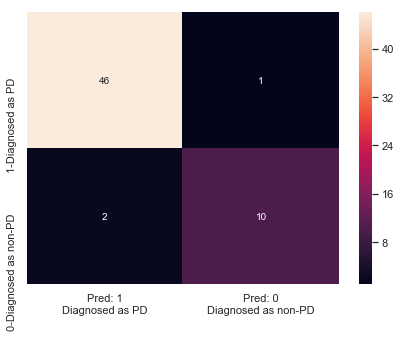

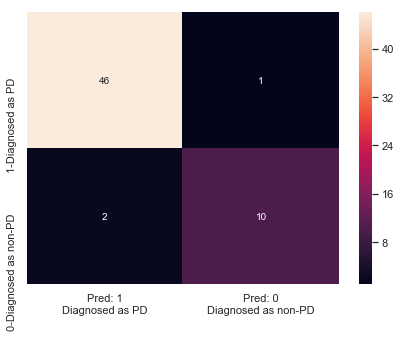

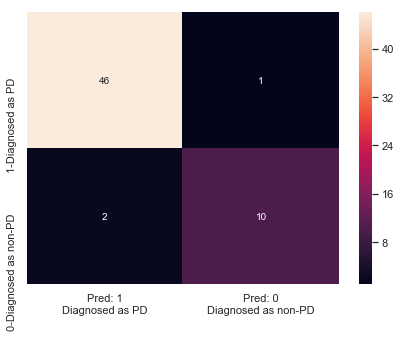

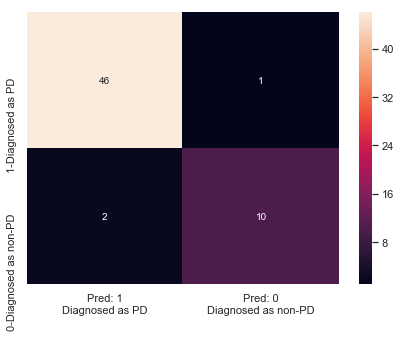

In [130]:
#Ensemble - Boosting - AdaBoost
from sklearn.ensemble import AdaBoostClassifier
model_names = []
model_scores = []
algo_name = "Adaptive Boosting"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):        
        clf = AdaBoostClassifier(n_estimators=25, learning_rate=0.2)
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

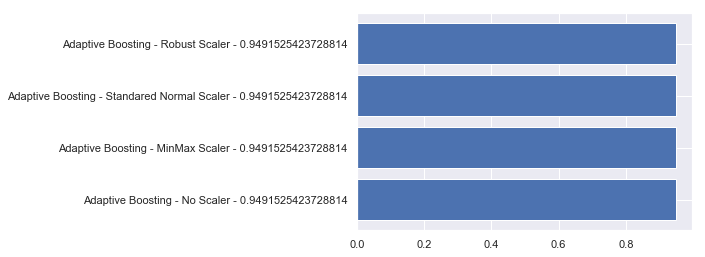

In [131]:
plt.barh(model_names, model_scores)
plt.show()

In [132]:
b("Robust Scaler - Adaptive Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Adaptive Boosting' as Robust scaler data performs better over others considering different models ouput")
fin_model_names.append("Robust Scaler - Adaptive Boosting")
fin_model_scores.append(0.9491525423728814)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Robust Scaler - Adaptive Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Adaptive Boosting' as Robust scaler data performs better over others considering different models ouput 


Gradient Boosting - Training Score on No Scaler dataset is 0.9485294117647058
Gradient Boosting - Test Score on No Scaler dataset is 0.9322033898305084
No Scaler - Gradient Boosting - Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.83      0.83        12
           0       0.96      0.96      0.96        47

    accuracy                           0.93        59
   macro avg       0.90      0.90      0.90        59
weighted avg       0.93      0.93      0.93        59

Gradient Boosting - Training Score on MinMax Scaler dataset is 0.9485294117647058
Gradient Boosting - Test Score on MinMax Scaler dataset is 0.9322033898305084
MinMax Scaler - Gradient Boosting - Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.83      0.83        12
           0       0.96      0.96      0.96        47

    accuracy                           0.93        59
   macro avg       0.90      

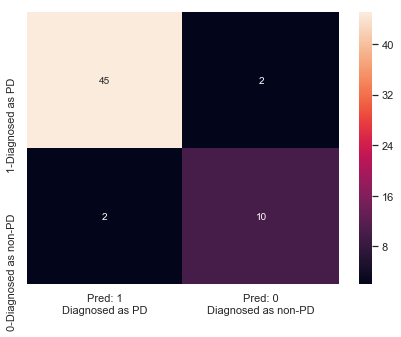

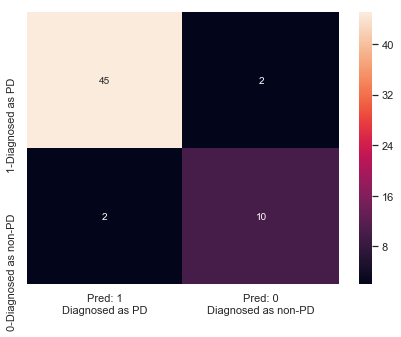

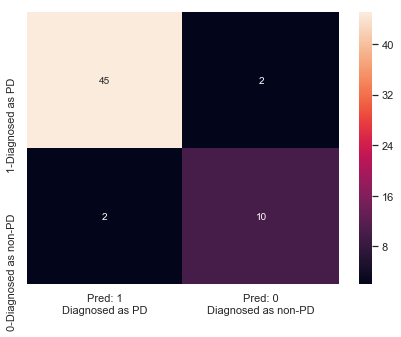

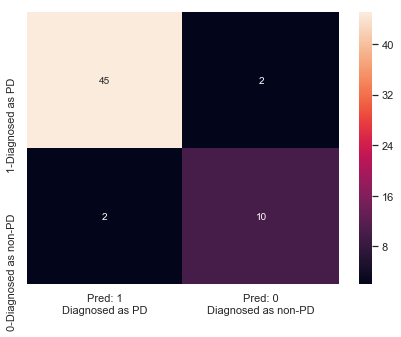

In [133]:
#Ensemble - Boosting - GradientBoost
from sklearn.ensemble import GradientBoostingClassifier
model_names = []
model_scores = []
algo_name = "Gradient Boosting"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):        
        clf = GradientBoostingClassifier(n_estimators=5, learning_rate=0.4, max_depth=2, random_state=0)
        clf.fit(X_train_dataset, y_train_labelset)
        y_pred = clf.predict(X_test_dataset)
        print("{0} - Training Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_train_dataset, y_train_labelset)))
        print("{0} - Test Score on {1} dataset is {2}".format(algo_name, scaler_type, clf.score(X_test_dataset, y_test_labelset)))
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

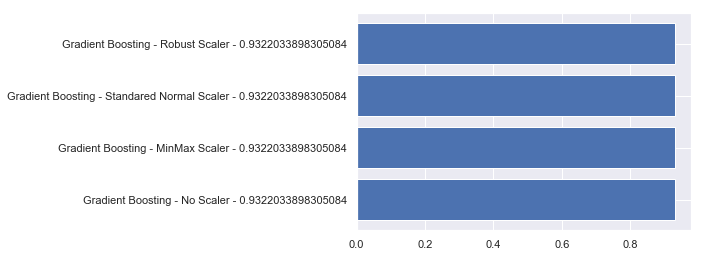

In [134]:
plt.barh(model_names, model_scores)
plt.show()

In [135]:
b("Robust Scaler - Gradient Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Gradient Boosting' as Robust scaler data performs better over others considering different models ouput")
fin_model_names.append("Robust Scaler - Gradient Boosting")
fin_model_scores.append(0.9322033898305084)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Robust Scaler - Gradient Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Gradient Boosting' as Robust scaler data performs better over others considering different models ouput 


No Scaler - Xtreme Gradient Boosting - Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.92      0.88        12
           0       0.98      0.96      0.97        47

    accuracy                           0.95        59
   macro avg       0.91      0.94      0.92        59
weighted avg       0.95      0.95      0.95        59

MinMax Scaler - Xtreme Gradient Boosting - Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.92      0.88        12
           0       0.98      0.96      0.97        47

    accuracy                           0.95        59
   macro avg       0.91      0.94      0.92        59
weighted avg       0.95      0.95      0.95        59

Standared Normal Scaler - Xtreme Gradient Boosting - Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.92      0.88        12
           0       0.98      0.96

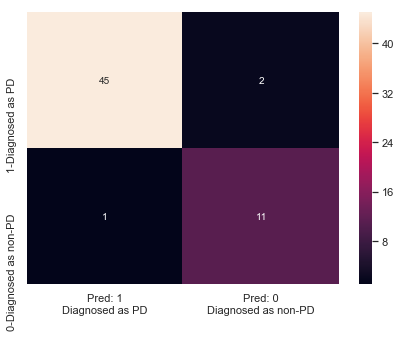

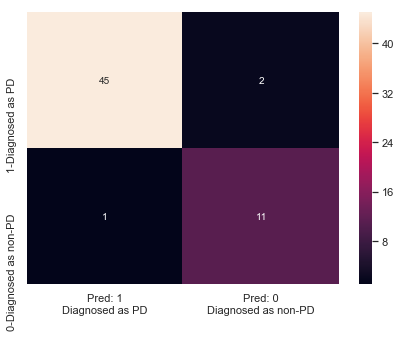

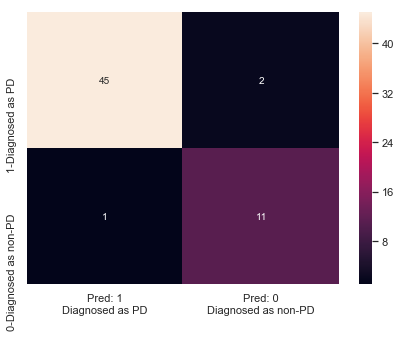

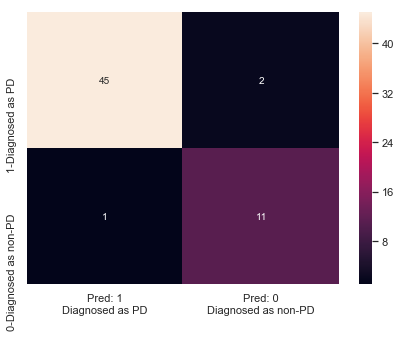

In [136]:
#Ensemble - Boosting - XGBM
import xgboost as xgb
model_names = []
model_scores = []
algo_name = "Xtreme Gradient Boosting"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):        
        iter_cnt=20
        X_dtrain = xgb.DMatrix(X_train_dataset, label=y_train_labelset)
        X_dtest = xgb.DMatrix(X_test_dataset)
        xgb_params = {'objective':'binary:logistic', 'max_depth':4, 'learning_rate':0.2}
        clf = xgb.train(xgb_params, X_dtrain, iter_cnt)
        y_pred = clf.predict(X_dtest)
        for i in range(0, len(y_pred)):
            if y_pred[i]>=0.5:
                y_pred[i]=1
            else:
                y_pred[i]=0
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

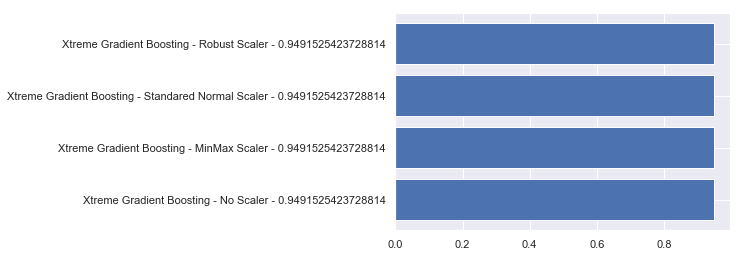

In [137]:
plt.barh(model_names, model_scores)
plt.show()

In [138]:
b("Robust Scaler - Xtreme Gradient Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Xtreme Gradient Boosting' as Robust scaler data performs better over others considering different models ouput")
fin_model_names.append("Robust Scaler - Xtreme Gradient Boosting")
fin_model_scores.append(0.949152)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Robust Scaler - Xtreme Gradient Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Robust Scaler - Xtreme Gradient Boosting' as Robust scaler data performs better over others considering different models ouput 


[LightGBM] [Info] Number of positive: 100, number of negative: 36
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 983
[LightGBM] [Info] Number of data points in the train set: 136, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.735294 -> initscore=1.021651
[LightGBM] [Info] Start training from score 1.021651
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

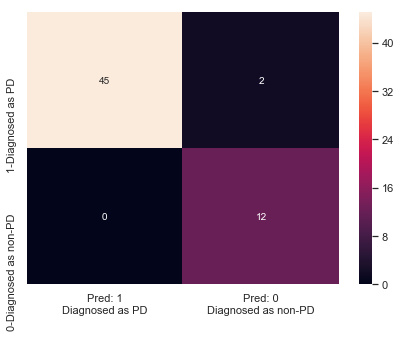

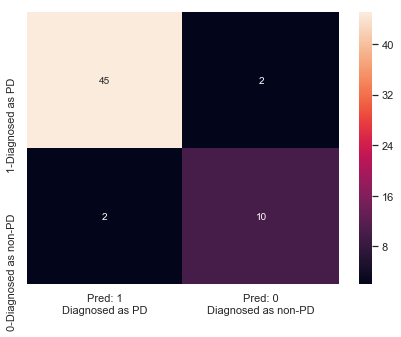

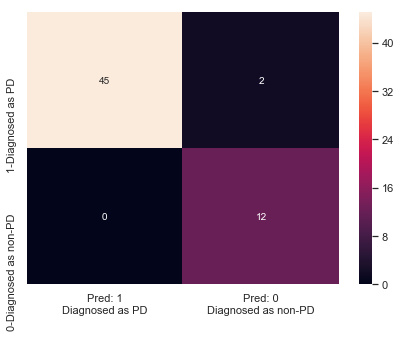

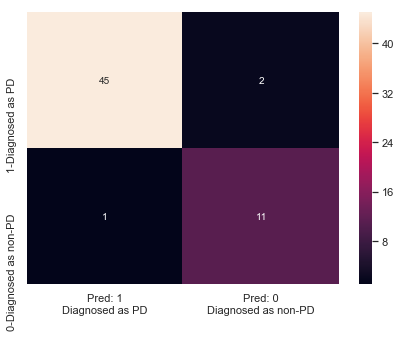

In [139]:
#Ensemble - Boosting - LightGBM
import lightgbm as lgb
model_names = []
model_scores = []
algo_name = "Light Gradient Boosting"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):        
        iter_cnt=20
        train_data = lgb.Dataset(X_train_dataset, label=y_train_labelset)
        lgbm_params = {'num_leaves':200, 'objective':'binary', 'max_depth':7, 'learning_rate':0.5}
        clf = lgb.train(lgbm_params, train_data, iter_cnt)
        y_pred = clf.predict(X_test_dataset)
        for i in range(0, len(y_pred)):
            if y_pred[i]>=0.5:
                y_pred[i]=1
            else:
                y_pred[i]=0
        target_values = map(str, df_org['status'].unique().tolist())
        print("{0} - {1} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_pred, target_names=list(target_values))))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=[1,0])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1-Diagnosed as PD","0-Diagnosed as non-PD"]], columns = [i for i in ["Pred: 1\nDiagnosed as PD","Pred: 0\nDiagnosed as non-PD"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')        
        pred_score = metrics.accuracy_score(y_test_labelset, y_pred)
        model_names.append("{0} - {1} - {2}".format(algo_name, scaler_type, pred_score))
        model_scores.append(pred_score)

In [140]:
model_names

['Light Gradient Boosting - No Scaler - 0.9661016949152542',
 'Light Gradient Boosting - MinMax Scaler - 0.9322033898305084',
 'Light Gradient Boosting - Standared Normal Scaler - 0.9661016949152542',
 'Light Gradient Boosting - Robust Scaler - 0.9491525423728814']

In [141]:
model_scores

[0.9661016949152542,
 0.9322033898305084,
 0.9661016949152542,
 0.9491525423728814]

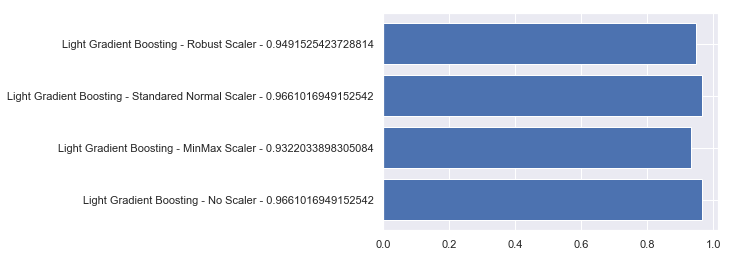

In [142]:
plt.barh(model_names, model_scores)
plt.show()

In [143]:
b("Standared Normal Scaler - Light Gradient Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Standared Normal Scaler - Light Gradient Boosting' as Robust scaler data performs better over others considering different models ouput")
fin_model_names.append("Standared Normal Scaler - Light Gradient Boosting")
fin_model_scores.append(0.9661016949152542)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Standared Normal Scaler - Light Gradient Boosting is performing the same on all normalized data types. Hence, I'm choosing the combination of 'Standared Normal Scaler - Light Gradient Boosting' as Robust scaler data performs better over others considering different models ouput 


## 9. Compare all the models (minimum 5) and pick the best one among them

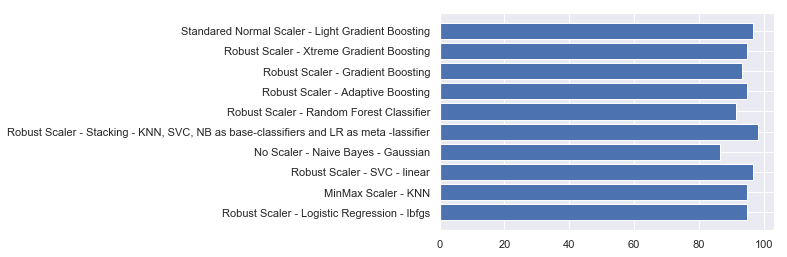

In [144]:
fin_model_scores
fin_model_scores_percentage = map(lambda x: x*100, fin_model_scores)
plt.barh(fin_model_names, list(fin_model_scores_percentage))
plt.show()

In [145]:
f("Out of any individual, bagging, boosting models, Stacking model i.e. 'Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier' performed extremely well in predicting both the classes with the accuracy score of 98.31%. Also, the trade off between bias and variance in the stacking model is considerably acceptable. Hence, it's evident that Stacking model outweighs all other algos for the given dataset after transforming the data with 'Robust Scaler'.")

 *********************************************************************************************************************** 
 Final Comments: 
 *********************************************************************************************************************** 
 Out of any individual, bagging, boosting models, Stacking model i.e. 'Stacking - KNN, SVC, NB as base-classifiers and LR as meta -classifier' performed extremely well in predicting both the classes with the accuracy score of 98.31%. Also, the trade off between bias and variance in the stacking model is considerably acceptable. Hence, it's evident that Stacking model outweighs all other algos for the given dataset after transforming the data with 'Robust Scaler'. 
